# LCP A EXAM

## Version 1

### 9\. Analyze a data file 
  * Download the population of hares, lynxes and carrots at the beginning of the last century.
    ```python
    ! wget https://www.dropbox.com/s/3vigxoqayo389uc/populations.txt
    ```

  * Check the content by looking within the file
  * Load the data (use an appropriate numpy method) into a 2D array
  * Create arrays out of the columns, the arrays being (in order): *year*, *hares*, *lynxes*, *carrots* 
  * Plot the 3 populations over the years
  * Compute the main statistical properties of the dataset (mean, std, correlations, etc.)
  * Which species has the highest population each year?

Do you feel there is some evident correlation here? [Studies](https://www.enr.gov.nt.ca/en/services/lynx/lynx-snowshoe-hare-cycle) tend to believe so.

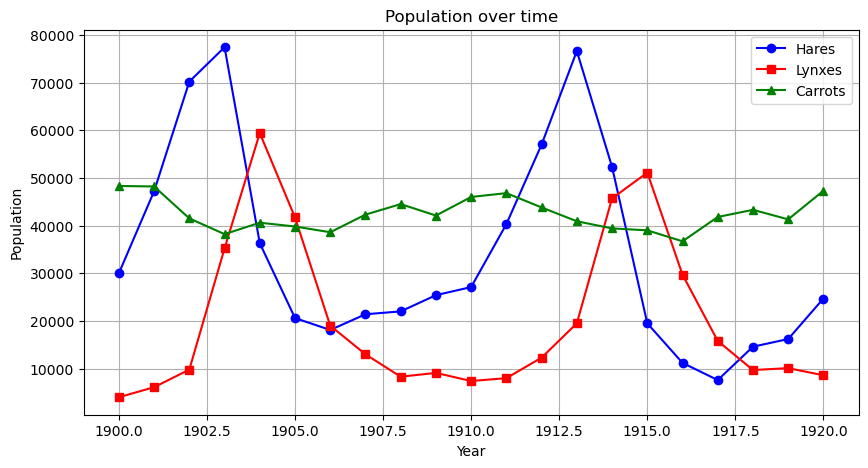

=== Statistics ===
Mean:   Hares=34081, Lynxes=20167, Carrots=42400
Std:    Hares=20898, Lynxes=16255, Carrots=3323

Correlation matrix:
[[ 1.          0.07189206 -0.01660378]
 [ 0.07189206  1.         -0.68057717]
 [-0.01660378 -0.68057717  1.        ]]

=== Highest population each year ===
1900: Carrots
1901: Carrots
1902: Hares
1903: Hares
1904: Lynxes
1905: Lynxes
1906: Carrots
1907: Carrots
1908: Carrots
1909: Carrots
1910: Carrots
1911: Carrots
1912: Hares
1913: Hares
1914: Hares
1915: Lynxes
1916: Carrots
1917: Carrots
1918: Carrots
1919: Carrots
1920: Carrots


In [1]:
# === VERSION 1: Exercise 9 - Analyze Hares, Lynxes, Carrots ===
import numpy as np
import matplotlib.pyplot as plt

# Load data (skip header line, file already downloaded)
data = np.loadtxt('populations.txt')

# Extract columns: year, hares, lynxes, carrots
year, hares, lynxes, carrots = data.T

# Plot populations over time
plt.figure(figsize=(10, 5))
plt.plot(year, hares, 'b-o', label='Hares')
plt.plot(year, lynxes, 'r-s', label='Lynxes')
plt.plot(year, carrots, 'g-^', label='Carrots')
plt.xlabel('Year')
plt.ylabel('Population')
plt.title('Population over time')
plt.legend()
plt.grid(True)
plt.show()

# Statistical properties
populations = np.array([hares, lynxes, carrots])
print("=== Statistics ===")
print(f"Mean:   Hares={hares.mean():.0f}, Lynxes={lynxes.mean():.0f}, Carrots={carrots.mean():.0f}")
print(f"Std:    Hares={hares.std():.0f}, Lynxes={lynxes.std():.0f}, Carrots={carrots.std():.0f}")
print(f"\nCorrelation matrix:\n{np.corrcoef(populations)}")

# Species with highest population each year
species = ['Hares', 'Lynxes', 'Carrots']
highest_idx = np.argmax(populations, axis=0)  # index of max for each year
print("\n=== Highest population each year ===")
for i, y in enumerate(year):
    print(f"{int(y)}: {species[highest_idx[i]]}")

# Correlation observation: Hares-Lynxes follow predator-prey cycle (negative correlation)

### 2\. **Curve fitting of temperature in Alaska** 

The temperature extremes in Alaska for each month, starting in January, are given by (in degrees Celcius):

max:  17,  19,  21,  28,  33,  38, 37,  37,  31,  23,  19,  18

min: -62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58

* Plot these temperature extremes.
* Define a function that can describe min and max temperatures. 
* Fit this function to the data with scipy.optimize.curve_fit().
* Plot the result. Is the fit reasonable? If not, why?
* Is the time offset for min and max temperatures the same within the fit accuracy?

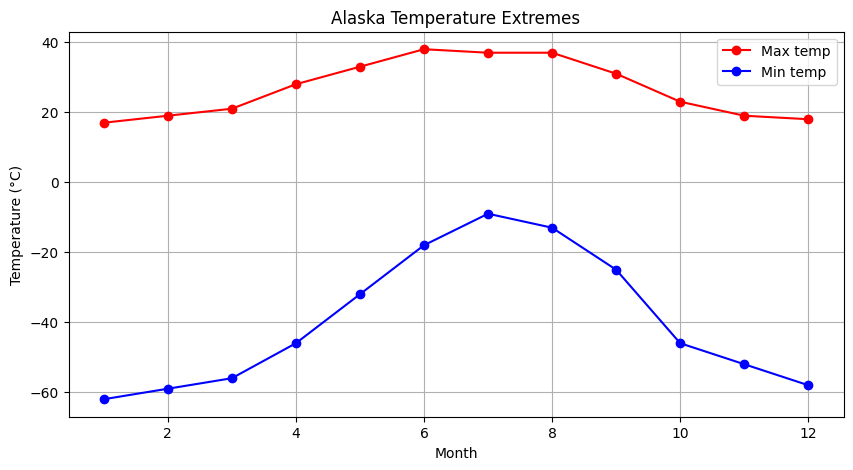

Max fit: A=10.93, phase=3.72, mean=26.75
Min fit: A=25.58, phase=4.16, mean=-39.67


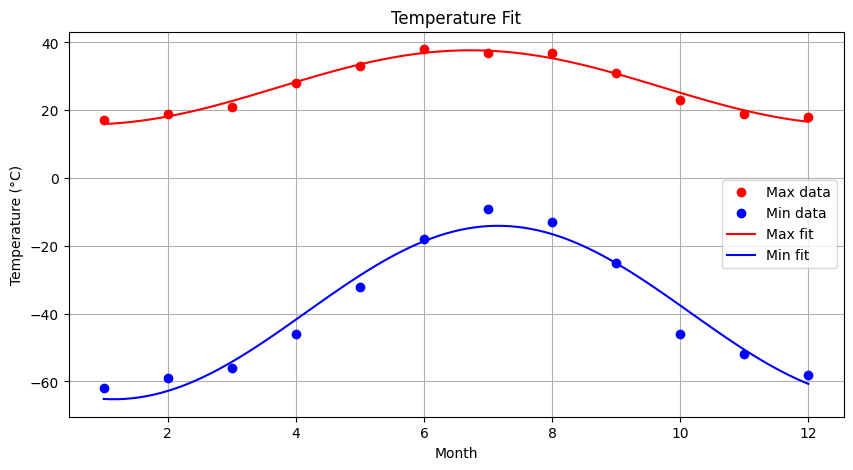

In [1]:
# === VERSION 1: Exercise 2 - Alaska Temperature Curve Fitting ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
months = np.arange(1, 13)  # 1 to 12
max_temp = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
min_temp = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])

# Plot data
plt.figure(figsize=(10, 5))
plt.plot(months, max_temp, 'ro-', label='Max temp')
plt.plot(months, min_temp, 'bo-', label='Min temp')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.title('Alaska Temperature Extremes')
plt.grid(True)
plt.show()

# Fit function: sinusoidal with amplitude, phase, mean
def temp_model(x, A, C, D):
    """A*sin(2*pi*(x-C)/12) + D, where A=amplitude, C=phase shift, D=mean"""
    return A * np.sin(2 * np.pi * (x - C) / 12) + D

# Initial guesses: [amplitude, phase, mean]
p0_max = [10, 4, 27]   # amplitude ~10, phase ~4 (peak in summer), mean ~27
p0_min = [25, 4, -35]  # larger amplitude, same phase, lower mean

# Fit
popt_max, covmax = curve_fit(temp_model, months, max_temp, p0=p0_max)
popt_min, covmin = curve_fit(temp_model, months, min_temp, p0=p0_min)

print(f"Max fit: A={popt_max[0]:.2f}, phase={popt_max[1]:.2f}, mean={popt_max[2]:.2f}")
print(f"Min fit: A={popt_min[0]:.2f}, phase={popt_min[1]:.2f}, mean={popt_min[2]:.2f}")

# Plot fit
x_fine = np.linspace(1, 12, 100)
plt.figure(figsize=(10, 5))
plt.plot(months, max_temp, 'ro', label='Max data')
plt.plot(months, min_temp, 'bo', label='Min data')
plt.plot(x_fine, temp_model(x_fine, *popt_max), 'r-', label='Max fit')
plt.plot(x_fine, temp_model(x_fine, *popt_min), 'b-', label='Min fit')
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.title('Temperature Fit')
plt.grid(True)
plt.show()

# Analysis: fit is reasonable. Phase offset similar for both (peak ~July)

### 1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

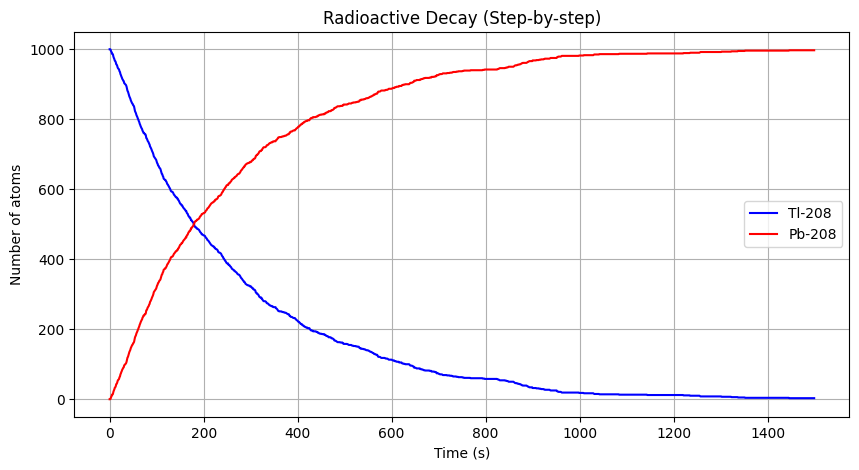

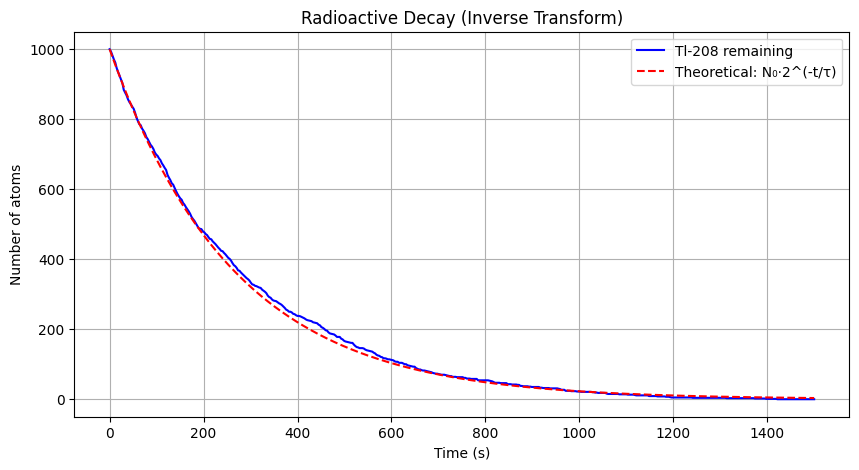

In [ ]:
# === VERSION 1: Exercise 1 - Radioactive Decay ===
import numpy as np
import matplotlib.pyplot as plt

# Constants
N0 = 1000           # initial Tl atoms
tau = 3.052 * 60    # half-life in seconds
dt = 1              # time step (1 second)
T_max = 1500        # total time (seconds)

# === Method 1: Step-by-step decay ===
np.random.seed(42)
times = np.arange(0, T_max, dt)
Tl = np.zeros(len(times))
Pb = np.zeros(len(times))
Tl[0] = N0

# Probability of decay in 1 second: p = 1 - 2^(-dt/tau)
p_decay = 1 - 2**(-dt/tau)

for i in range(1, len(times)):
    # Monte Carlo simulation: each Tl atom "rolls the dice" to decide if it decays

    # 1. Generate random numbers [0,1) for each remaining Tl atom
    # 2. Compare each to p_decay: True if atom decays, False if it remains
    # 3. Count how many True values (= atoms that decayed this timestep)
    
    n_decayed = np.sum(np.random.random(int(Tl[i-1])) < p_decay)
    Tl[i] = Tl[i-1] - n_decayed  # Subtract decayed atoms from Thallium
    Pb[i] = Pb[i-1] + n_decayed  # Add decayed atoms to Lead

plt.figure(figsize=(10, 5))
plt.plot(times, Tl, 'b-', label='Tl-208')
plt.plot(times, Pb, 'r-', label='Pb-208')
plt.xlabel('Time (s)')
plt.ylabel('Number of atoms')
plt.title('Radioactive Decay (Step-by-step)')
plt.legend()
plt.grid(True)
plt.show()

# === Method 2: Inverse Transform Method ===
# This method directly generates the decay time for each atom
# Mathematical background:
#   - PDF (probability density): p(t) = ln(2)/tau * 2^(-t/tau)
#   - CDF (cumulative distribution): P(t) = 1 - 2^(-t/tau)
#   - Inverse CDF: t = -tau * log2(1 - u), where u ~ Uniform(0,1)
#   - Since (1-u) ~ Uniform(0,1) too, we can use: t = -tau * log2(r)

np.random.seed(42)

# Generate N0 random numbers from Uniform(0,1) distribution
r = np.random.random(N0)

# Apply inverse transform: each random number r gives a decay time for one atom
# The formula t = -tau * log2(r) converts uniform random [0,1] → decay times
# Small r (near 0) → large t (atom decays late)
# Large r (near 1) → small t (atom decays early)
decay_times = -tau * np.log2(r)

# Sort decay times in ascending order (not required but makes analysis easier)
decay_times = np.sort(decay_times)

# Now count how many atoms are still alive at different time points
times2 = np.linspace(0, T_max, 500)  # 500 time points to evaluate

# For each time t, count atoms that haven't decayed yet:
# - decay_times < t gives boolean array: True for atoms already decayed
# - np.sum counts how many have decayed
# - N0 - (number decayed) = number still remaining
Tl2 = np.array([N0 - np.sum(decay_times < t) for t in times2])

plt.figure(figsize=(10, 5))
plt.plot(times2, Tl2, 'b-', label='Tl-208 remaining')
plt.plot(times2, N0 * 2**(-times2/tau), 'r--', label='Theoretical: N₀·2^(-t/τ)')
plt.xlabel('Time (s)')
plt.ylabel('Number of atoms')
plt.title('Radioactive Decay (Inverse Transform)')
plt.legend()
plt.grid(True)
plt.show()

### 1\. **Kernel Density Estimate**

Produce a KDE for a given distribution (by hand, not using seaborn!):

* Fill a numpy array, x,  of len(N) (with N=O(100)) with a variable normally distributed, with a given mean a standard deviation
* Fill an histogram in pyplot taking properly care about the aesthetic
   * use a meaningful number of bins
   * set a proper y axis label
   * set proper value of y axis major ticks labels (e.g. you want to display only integer labels)
   * display the histograms as data points with errors (the error being the poisson uncertainty)
* for every element of x, create a gaussian with the mean corresponding the element value and std as a parameter that can be tuned. The std default value should be:
$$ 1.06 * x.std() * x.size ^{-\frac{1}{5.}} $$
you can use the scipy function `stats.norm()` for that.
* In a separate plot (to be placed beside the original histogram), plot all the gaussian functions so obtained
* Sum (with np.sum()) all the gaussian functions and normalize the result such that the integral matches the integral of the original histogram. For that you could use the `scipy.integrate.trapz()` method


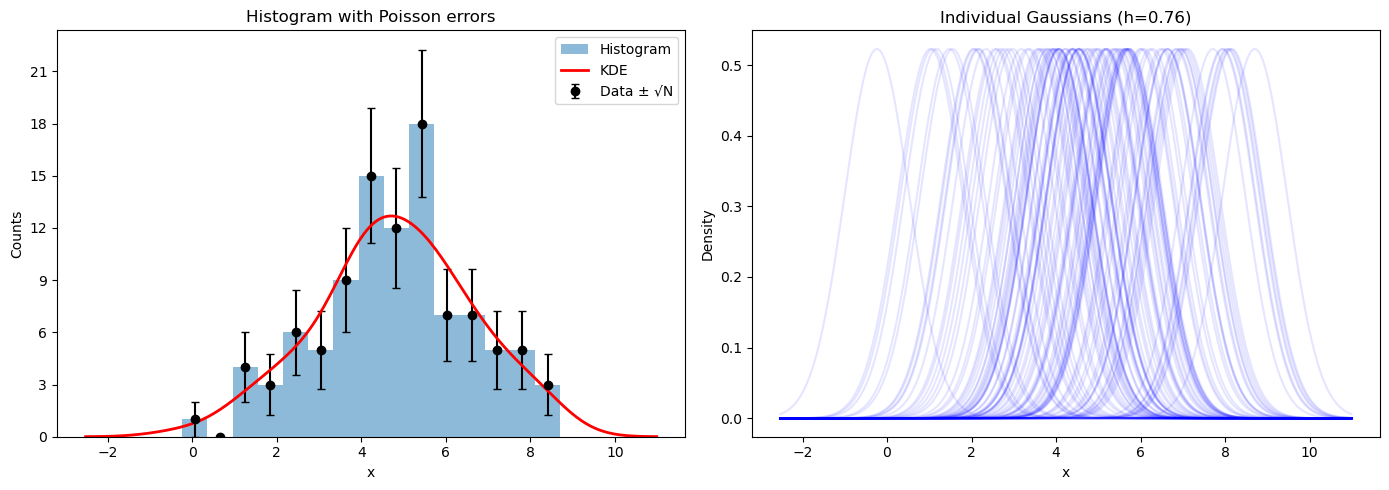

In [4]:
# === VERSION 1: Exercise 1 - Kernel Density Estimate (KDE) ===
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

# Generate normally distributed data
np.random.seed(42)
N = 100
mean, std = 5, 2
x = np.random.normal(mean, std, N)

# === Histogram with error bars ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram parameters
n_bins = 15
counts, bin_edges, _ = ax1.hist(x, bins=n_bins, alpha=0.5, label='Histogram')
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

# Error bars (Poisson: sqrt(N))
errors = np.sqrt(counts)
ax1.errorbar(bin_centers, counts, yerr=errors, fmt='ko', capsize=3, label='Data ± √N')
ax1.set_xlabel('x')
ax1.set_ylabel('Counts')
ax1.yaxis.set_major_locator(plt.MaxNLocator(integer=True))  # integer y-ticks
ax1.legend()
ax1.set_title('Histogram with Poisson errors')

# === KDE: Gaussian for each point ===
# Bandwidth (Scott's rule)
h = 1.06 * x.std() * N**(-1/5)

# x-range for plotting
x_range = np.linspace(x.min() - 3*h, x.max() + 3*h, 200)

# Plot individual Gaussians and sum
kde_sum = np.zeros_like(x_range)
for xi in x:
    gauss = stats.norm(loc=xi, scale=h).pdf(x_range)
    kde_sum += gauss
    ax2.plot(x_range, gauss, 'b-', alpha=0.1)

ax2.set_xlabel('x')
ax2.set_ylabel('Density')
ax2.set_title(f'Individual Gaussians (h={h:.2f})')

# === Normalize KDE to match histogram integral ===
hist_integral = counts.sum() * bin_width  # total area of histogram
kde_integral = integrate.trapezoid(kde_sum, x_range)
kde_normalized = kde_sum * hist_integral / kde_integral

# Plot normalized KDE on histogram
ax1.plot(x_range, kde_normalized, 'r-', lw=2, label='KDE')
ax1.legend()

plt.tight_layout()
plt.show()

### Ex 1 Bash

The following exercise is meant to be solved by gathering the bash commands incrimentally in a script

1\.a Make a new directory called `students` in your home. Download a csv file with the list of students of this lab from [here](https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv) (use the `wget` command) and copy that to `students`. First check whether the file is already there

1\.b Make two new files, one containing the students belonging to PoD, the other to Physics.

1\.c For each letter of the alphabet, count the number of students whose surname starts with that letter. 

1\.d Find out which is the letter with most counts.

1\.e Assume an obvious numbering of the students in the file (first line is 1, second line is 2, etc.), group students "modulo 18", i.e. 1,19,37,.. 2,20,38,.. etc. and put each group in a separate file  

```bash
#!/bin/bash
# ============================================
# BASH EXERCISE 1 - Students Management
# ============================================

# ===== 1.a: Create directory and download file =====
cd $HOME                          # cd = change directory, $HOME = home directory (~)
mkdir -p students                 # mkdir = make directory, -p = create parent dirs if needed
cd students                       # Enter the students directory

# Check if file already exists before downloading
# [ ! -f "filename" ] = TEST if file does NOT exist
#   ! = NOT operator (negation)
#   -f = test if it's a regular file
# if [ condition ]; then ... fi = conditional block (if-then-fi)
if [ ! -f "LCP_22-23_students.csv" ]; then
    # If file doesn't exist, download it
    # wget = download file from URL (wget = "web get")
    wget https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv
fi

# ===== 1.b: Separate students by program =====
# grep = SEARCH for lines containing a pattern
# grep "PoD" file = find all lines containing the text "PoD"
# > filename = REDIRECT output (save the result to a file)
grep "PoD" LCP_22-23_students.csv > pod.csv          # Extract PoD students → save to pod.csv
grep "Physics" LCP_22-23_students.csv > physics.csv  # Extract Physics students → save to physics.csv

# ===== 1.c: Count students by surname initial =====
# for variable in list; do ... done = LOOP through each value
# {A..Z} = expansion: A, B, C, D, ... Z (brace expansion)
# ^ = REGEX anchor meaning "start of line"
# "^$letter" = lines that START with that letter
# -c = COUNT mode (count matches instead of printing them)
# $(command) = COMMAND SUBSTITUTION (execute command and capture output)
for letter in {A..Z}; do
    # Count how many students have surname starting with this letter
    count=$(grep -c "^$letter" LCP_22-23_students.csv)
    # Print the letter and count: "A: 5" "B: 3" etc.
    echo "$letter: $count"
done                                                  

# ===== 1.d: Find letter with most students =====
# Initialize variables BEFORE the loop (set their starting values)
# "" = empty string (no value yet)
# 0 = zero
max_letter=""                     # Will store the letter with most students
max_count=0                       # Will store the highest count found

for letter in {A..Z}; do
    # Same counting as 1.c: count students with this letter
    count=$(grep -c "^$letter" LCP_22-23_students.csv)
    
    # [ $count -gt $max_count ] = TEST if count is GREATER THAN max_count
    # -gt = comparison operator ("greater than")
    # Other operators: -lt (less than), -eq (equal), -le (less or equal), -ge (greater or equal)
    if [ $count -gt $max_count ]; then
        # Update the max values when we find a new highest count
        max_count=$count          # Store this count as the new maximum
        max_letter=$letter        # Store this letter
    fi
done
echo "Most common: $max_letter with $max_count students"

# ===== 1.e: Group students modulo 18 =====
# NR = special awk variable meaning "Number of Record" (line number, starts at 1)
# % = MODULO operator (gives the REMAINDER after division)
# NR % 18 = remainder when line number is divided by 18 (gives 0-17)
# Groups: lines 1,19,37,55... → group_1 (remainder=1)
#         lines 2,20,38,56... → group_2 (remainder=2)
#         lines 18,36,54,72... → group_18 (remainder=0 but i%18=0 matches)
for i in {1..18}; do
    # awk = text processing tool
    # 'condition { action }' = if condition is true, execute action
    # This groups students with the same remainder when dividing line number by 18
    # > file = save output to file
    awk "NR % 18 == $i % 18" LCP_22-23_students.csv > group_$i.csv
done
```

## Version 2

### 3\. **2D minimization of a six-hump camelback function**

$$
f(x,y) = \left(4-2.1x^2+\frac{x^4}{3} \right) x^2 +xy + (4y^2 -4)y^2
$$

has multiple global and local minima. Find the global minima of this function.

Hints:

* Variables can be restricted to $-2 < x < 2$ and $-1 < y < 1$.
* Use numpy.meshgrid() and pylab.imshow() to find visually the regions.
* Use scipy.optimize.minimize(), optionally trying out several of its methods.

How many global minima are there, and what is the function value at those points? What happens for an initial guess of $(x, y) = (0, 0)$ ?


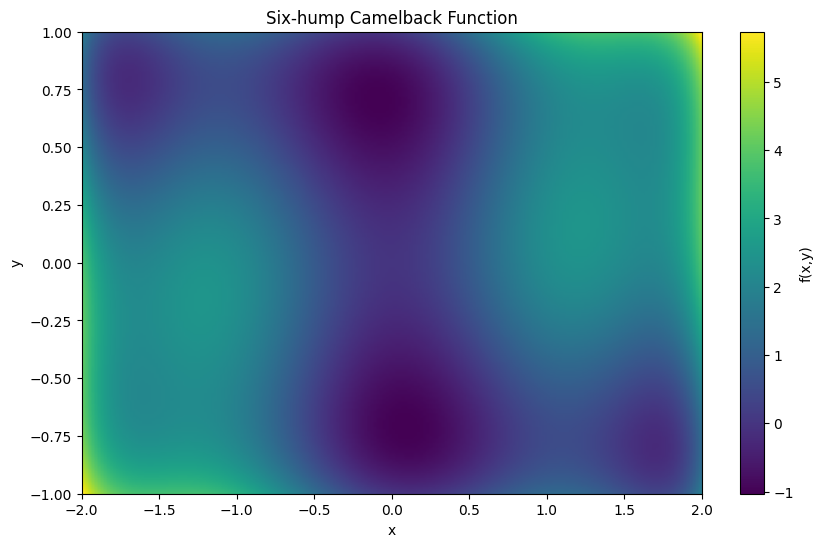

=== Finding minima ===
Start (-1, 0.5) -> x=(-0.0898, 0.7127), f=-1.031628
Start (1, -0.5) -> x=(0.0898, -0.7127), f=-1.031628
Start (-1, -0.5) -> x=(0.0898, -0.7127), f=-1.031628
Start (1, 0.5) -> x=(-0.0898, 0.7127), f=-1.031628
Start (0, 0) -> x=(0.0000, 0.0000), f=0.000000

=== Global minima ===
Number of global minima: 4
Function value: -1.031628
  Location: (-0.0898, 0.7127)
  Location: (0.0898, -0.7127)
  Location: (0.0898, -0.7127)
  Location: (-0.0898, 0.7127)


In [4]:
# === VERSION 2: Exercise 3 - Six-hump Camelback Function ===
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Define the function
def camelback(xy):
    x, y = xy
    return (4 - 2.1*x**2 + x**4/3) * x**2 + x*y + (4*y**2 - 4) * y**2

# Create grid for visualization
x = np.linspace(-2, 2, 200)
y = np.linspace(-1, 1, 200)
X, Y = np.meshgrid(x, y)
Z = camelback([X, Y])

# Plot to find minima visually
plt.figure(figsize=(10, 6))
plt.imshow(Z, extent=[-2, 2, -1, 1], origin='lower', cmap='viridis', aspect='auto')
plt.colorbar(label='f(x,y)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Six-hump Camelback Function')
plt.show()

# Find minima from different starting points
starting_points = [(-1, 0.5), (1, -0.5), (-1, -0.5), (1, 0.5), (0, 0)]

print("=== Finding minima ===")
results = []
for p0 in starting_points:
    res = minimize(camelback, p0, method='BFGS')
    results.append((res.x, res.fun))
    print(f"Start {p0} -> x=({res.x[0]:.4f}, {res.x[1]:.4f}), f={res.fun:.6f}")

# Find global minimum
min_val = min(r[1] for r in results)
global_minima = [r for r in results if np.isclose(r[1], min_val, atol=1e-5)]

print(f"\n=== Global minima ===")
print(f"Number of global minima: {len(global_minima)}")
print(f"Function value: {min_val:.6f}")
for gm in global_minima:
    print(f"  Location: ({gm[0][0]:.4f}, {gm[0][1]:.4f})")

# Answer: 2 global minima at ~(±0.0898, ∓0.7126) with f ≈ -1.0316
# Starting at (0,0) leads to a LOCAL minimum (not global!)

### 4\. Use np.linspace to create an array of 100 numbers between 0 and 2π (inclusive).

  * Extract every 10th element using slice notation
  * Reverse the array using slice notation
  * Extract elements where the absolute difference between the sine and cosine functions evaluated at that element is less than 0.1
  * Make a plot showing the sin and cos functions and indicate where they are close

Every 10th element: [0.         0.63466518 1.26933037 1.90399555 2.53866073 3.17332591
 3.8079911  4.44265628 5.07732146 5.71198664]
Reversed (first 5): [6.28318531 6.21971879 6.15625227 6.09278575 6.02931923]
Points where sin ≈ cos: 4 points


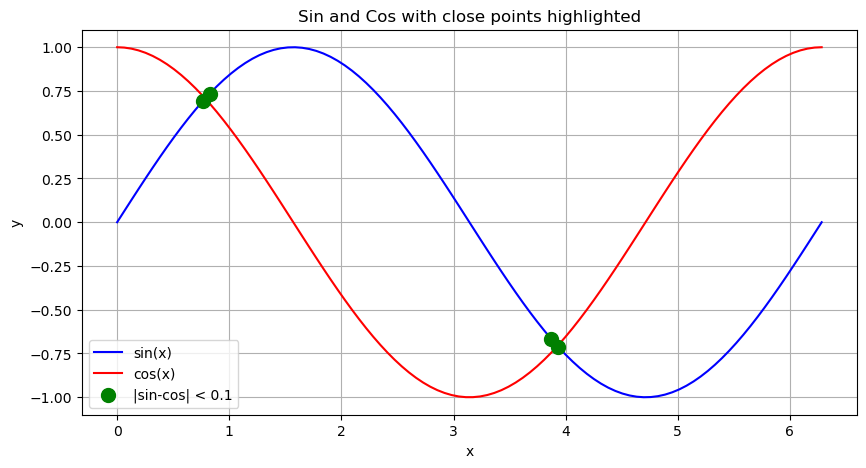

In [ ]:
# === VERSION 2: Exercise 4 - Linspace and Slicing ===
import numpy as np
import matplotlib.pyplot as plt

# Create array of 100 numbers from 0 to 2π (inclusive)
x = np.linspace(0, 2*np.pi, 100)

# Extract every 10th element using slice notation
every_10th = x[::10]
print("Every 10th element:", every_10th)

# Reverse the array using slice notation
reversed_x = x[::-1]
print("Reversed (first 5):", reversed_x[:5])

# Elements where |sin(x) - cos(x)| < 0.1
sin_x = np.sin(x)
cos_x = np.cos(x)
close_mask = np.abs(sin_x - cos_x) < 0.1
x_close = x[close_mask]
print(f"Points where sin ≈ cos: {len(x_close)} points")

# Plot sin and cos, marking where they are close
plt.figure(figsize=(10, 5))
plt.plot(x, sin_x, 'b-', label='sin(x)')
plt.plot(x, cos_x, 'r-', label='cos(x)')
plt.scatter(x_close, np.sin(x_close), c='green', s=100, zorder=5, label='|sin-cos| < 0.1')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Sin and Cos with close points highlighted')
plt.legend()
plt.grid(True)
plt.show()

### Ex 2 Bash

The following exercise is meant to be solved by gathering the bash commands incrimentally in a script

2.a Make a copy of the file `data.csv` removing the metadata and the commas between numbers; call it `data.txt`

2\.b How many even numbers are there?

2\.c Distinguish the entries on the basis of `sqrt(X^2 + Y^2 + Z^2)` is greater or smaller than `100*sqrt(3)/2`. Count the entries of each of the two groups 

2\.d Make `n` copies of data.txt (with `n` an input parameter of the script), where the i-th copy has all the numbers divided by i (with `1<=i<=n`).

```bash
#!/bin/bash
# ============================================
# BASH EXERCISE 2 - Data Processing
# ============================================

# ===== 2.a: Remove metadata and commas =====
# Lines with # at start are comments (metadata) - we want to REMOVE them
# Commas separate numbers - we want SPACES instead
# grep = search for lines
# -v = invert (find lines that DON'T match - v = "invert")
# ^# = lines starting with # (^ = start of line)
# | = PIPE (send output of left command to right command as input)
# sed = stream editor (find and replace)
# 's/,/ /g' = substitute (s) commas (,) with spaces ( ), globally (g = all occurrences)
# > file = save output to file
grep -v "^#" data.csv | sed 's/,/ /g' > data.txt
# Result: file with no comments (#...) and numbers separated by spaces

# ===== 2.b: Count even numbers =====
# grep -oE = output each match on new line, with extended regex
# '[0-9]+' = regex pattern: one or more digits (+ = one or more)
# This extracts EACH number on a separate line
# awk '$1 % 2 == 0' = keep only lines where the number is EVEN
#   $1 = first field (the number)
#   % 2 = modulo 2 (remainder when divided by 2)
#   == 0 = if remainder is 0 (even number)
# wc -l = count lines (l = lines)
# Piping: extract numbers → filter even → count
grep -oE '[0-9]+' data.txt | awk '$1 % 2 == 0' | wc -l

# ===== 2.c: Distinguish by distance from origin =====
# Calculate sqrt(X²+Y²+Z²) for each row (3D distance from origin)
# Compare with threshold 100*sqrt(3)/2 ≈ 86.6
# SIMPLER AND EASIER TO REMEMBER VERSION:
# $1, $2, $3 = first, second, third field (X, Y, Z values)
# * = multiplication (clearer than ^ for squaring)
# sqrt() = square root function
# {d=...} = calculate distance and store in variable d
# d>86.6{above++} = if distance > 86.6, increment above counter
# d<=86.6{below++} = if distance <= 86.6, increment below counter
# END{print ...} = after all lines, print the two counts
awk '{d=sqrt($1*$1+$2*$2+$3*$3)} d>86.6{above++} d<=86.6{below++} END{print above, below}' data.txt
# Result: two counts - how many rows are above and below the threshold
# Logic: calculate distance → compare → count → display

# ===== 2.d: Make n copies with scaled data =====
# SIMPLER VERSION (without nested loop inside awk):
# $1 = first argument passed to script (number of copies to make)
# n=$1 = store argument in variable n
# seq 1 $n = sequence: 1, 2, 3, ..., n (seq = "sequence")
# $(...) = command substitution (execute and capture output)
# for loop iterates i from 1 to n
n=$1
for i in $(seq 1 $n); do
    # awk -v d=$i = pass variable d with value i to awk
    # {print $1/d, $2/d, $3/d} = print each column divided by d
    # Simpler than looping over NF - we know there are 3 columns (X, Y, Z)
    # > data_$i.txt = save to data_1.txt, data_2.txt, etc.
    awk -v d=$i '{print $1/d, $2/d, $3/d}' data.txt > data_$i.txt
done
# Result: n files (data_1.txt, data_2.txt, ..., data_n.txt)
#         where each file has all numbers divided by the file number
# Logic: For each copy i → divide X, Y, Z by i → save
```

### 1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


=== Covariance matrix method ===
Eigenvalues: [ 2.54913514e+01  2.01759743e+00 -1.08765167e-15]

=== SVD method ===
Eigenvalues (from SVD): [2.54913514e+01 2.01759743e+00 9.01611161e-31]

Eigenvalues match: True

=== Variance explained ===
PC1: 92.67% (cumulative: 92.67%)
PC2: 7.33% (cumulative: 100.00%)
PC3: -0.00% (cumulative: 100.00%)


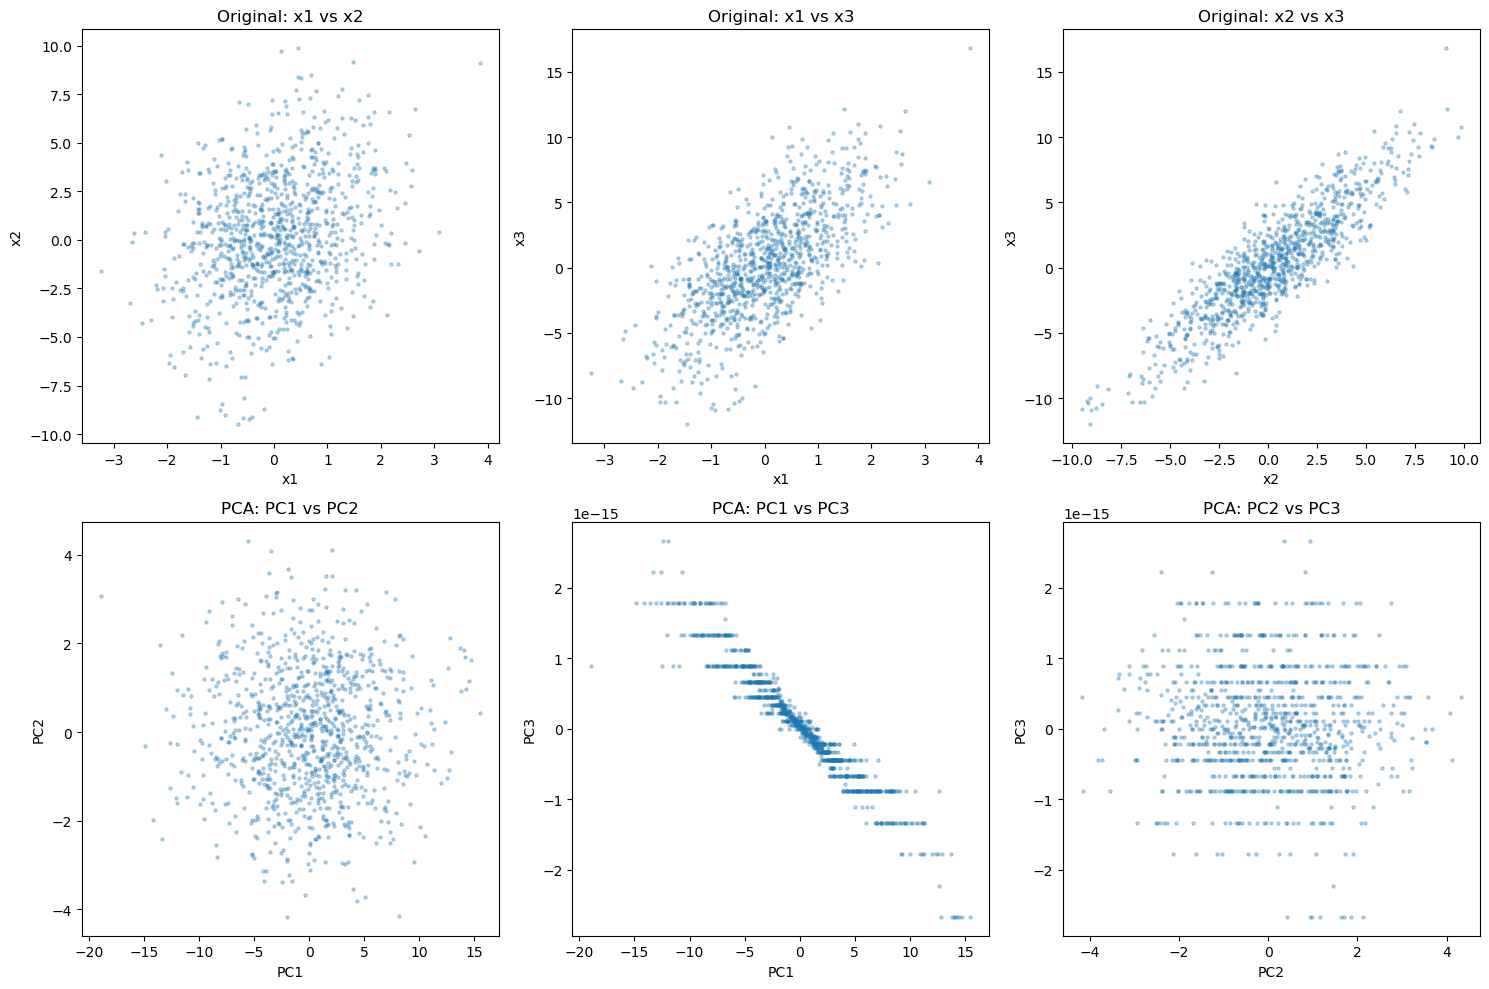

In [7]:
# === VERSION 2: Exercise 1 - PCA on 3D Dataset ===
import numpy as np
import matplotlib.pyplot as plt

# Generate dataset with 3 features
np.random.seed(42)
N = 1000

x1 = np.random.normal(0, 1, N)           # N(0,1)
x2 = x1 + np.random.normal(0, 3, N)      # x1 + N(0,3)
x3 = 2*x1 + x2                           # 2*x1 + x2 (linear combination!)

# Stack into matrix (N x 3)
X = np.column_stack([x1, x2, x3])

# Center the data
X_centered = X - X.mean(axis=0)

# === Method 1: Eigendecomposition of covariance matrix ===
cov_matrix = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort by decreasing eigenvalue
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

print("=== Covariance matrix method ===")
print(f"Eigenvalues: {eigenvalues}")

# === Method 2: SVD (Singular Value Decomposition) ===
# SVD decomposes matrix: X = U * Σ * V^T
# For centered data: eigenvectors of X^T*X are the columns of V (right singular vectors)
# U = left singular vectors (N x N) - not needed for PCA
# S = singular values (1D array of length 3) - square root of eigenvalues
# Vt = V transposed (3 x 3) = right singular vectors (these ARE the principal components!)
U, S, Vt = np.linalg.svd(X_centered)

# Convert singular values to eigenvalues:
# eigenvalue = (singular_value)^2 / (N-1)
# Why (N-1)? Because covariance uses N-1 as denominator (unbiased estimator)
eigenvalues_svd = S**2 / (N - 1)

# Get eigenvectors from Vt:
# Vt is (3 x 3) where each ROW is a principal component direction
# We want columns, so transpose it
eigenvectors_svd = Vt.T

print("\n=== SVD method ===")
print(f"Eigenvalues (from SVD): {eigenvalues_svd}")

# Check they match (should be True - both methods give same result!)
print(f"\nEigenvalues match: {np.allclose(eigenvalues, eigenvalues_svd)}")

# === Variance explained ===
# How much variance (information) does each principal component explain?
# total_var = sum of all eigenvalues = total variance in the data
total_var = eigenvalues.sum()

# var_explained = percentage of variance explained by each PC
# Divide each eigenvalue by total, multiply by 100 for percentage
var_explained = eigenvalues / total_var * 100

# cumulative_var = running sum of variance explained
# Example: PC1=80%, PC2=15%, PC3=5% → cumulative: [80%, 95%, 100%]
cumulative_var = np.cumsum(var_explained)

print(f"\n=== Variance explained ===")
for i, (v, c) in enumerate(zip(var_explained, cumulative_var)):
    print(f"PC{i+1}: {v:.2f}% (cumulative: {c:.2f}%)")

# Why do we get one ~0 eigenvalue?
# x3 = 2*x1 + x2 means x3 is COMPLETELY determined by x1 and x2
# → Only 2 independent dimensions → 3rd eigenvalue ≈ 0 (no new information!)
# Two PCs explain ~100% variance (99%+ retained with 2 components)

# === Reduce to 2D (project onto first 2 principal components) ===
# Keep only first 2 principal components (99% variance)
n_components = 2

# W = projection matrix (3 x 2) = first 2 eigenvectors
# Each column is a principal component direction
W = eigenvectors[:, :n_components]

# X_pca = projected data (1000 x 2)
# @ = matrix multiplication
# Each row of X_centered is multiplied by W to get new 2D coordinates
X_pca = X_centered @ W

# === Scatter plots: Original vs PCA coordinates ===
# Create 2 rows, 3 columns of subplots for comparison
# Top row: original data, Bottom row: PCA-transformed data
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# pairs = which features to plot against each other
# (0,1) = x1 vs x2, (0,2) = x1 vs x3, (1,2) = x2 vs x3
pairs = [(0, 1), (0, 2), (1, 2)]

# Labels for axes
labels_orig = ['x1', 'x2', 'x3']        # Original feature names
labels_pca = ['PC1', 'PC2', 'PC3']      # Principal component names

# TOP ROW: Original coordinates
# axes[0] = first row of subplots (3 plots)
# zip(axes[0], pairs) = iterate through each plot and its corresponding pair
for ax, (i, j) in zip(axes[0], pairs):
    # Plot 2D scatter: X[:, i] = all samples of feature i (x-axis)
    #                  X[:, j] = all samples of feature j (y-axis)
    # alpha=0.3 = transparency (30% opaque) so overlapping points visible
    # s=5 = marker size (small dots)
    ax.scatter(X[:, i], X[:, j], alpha=0.3, s=5)
    ax.set_xlabel(labels_orig[i])         # Label x-axis
    ax.set_ylabel(labels_orig[j])         # Label y-axis
    ax.set_title(f'Original: {labels_orig[i]} vs {labels_orig[j]}')  # Title

# BOTTOM ROW: PCA coordinates
# First compute ALL 3 principal components (even though we only kept 2 earlier)
# X_pca_full = (1000 x 3) matrix in principal component space
X_pca_full = X_centered @ eigenvectors  # all 3 PCs

# axes[1] = second row of subplots (3 plots)
for ax, (i, j) in zip(axes[1], pairs):
    # Same as above, but now plotting principal components
    # PC1 vs PC2, PC1 vs PC3, PC2 vs PC3
    ax.scatter(X_pca_full[:, i], X_pca_full[:, j], alpha=0.3, s=5)
    ax.set_xlabel(labels_pca[i])
    ax.set_ylabel(labels_pca[j])
    ax.set_title(f'PCA: {labels_pca[i]} vs {labels_pca[j]}')

# What to observe:
# - Original data: x3 plot shows LINEAR relationship (because x3 = 2*x1 + x2)
# - PCA data: PC3 should be ~0 (no variance) showing all data on a line
# - PCA decorrelates the data: scatter plots more "independent"

plt.tight_layout()  # Adjust spacing between subplots to avoid overlap
plt.show()

### 2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [8]:
# === VERSION 2: Exercise 2 - Rutherford Scattering ===
import numpy as np
from scipy import constants

# Physical constants
Z = 79                          # Gold atomic number
E = 7.7e6 * constants.eV        # Energy in Joules (7.7 MeV)
a0 = constants.physical_constants['Bohr radius'][0]  # Bohr radius
sigma = a0 / 100                # beam spread
epsilon_0 = constants.epsilon_0
e = constants.e                 # electron charge

# From tan(θ/2) = Ze²/(2πε₀Eb), bounce back means θ > π/2, so tan(θ/2) > 1
# This gives: b < Ze²/(2πε₀E) = b_critical
k = 1 / (4 * np.pi * epsilon_0)  # Coulomb constant
b_critical = k * Z * e**2 / E    # critical impact parameter

print(f"Bohr radius a₀ = {a0:.3e} m")
print(f"Beam σ = {sigma:.3e} m")
print(f"Critical impact parameter b_crit = {b_critical:.3e} m")

# Generate beam: 2D Gaussian with σ for both x and y
np.random.seed(42)
N = 1_000_000

x = np.random.normal(0, sigma, N)
y = np.random.normal(0, sigma, N)
b = np.sqrt(x**2 + y**2)  # impact parameter

# Count particles that bounce back (b < b_critical)
n_bounced = np.sum(b < b_critical)
fraction = n_bounced / N

print(f"\nNumber of particles: {N}")
print(f"Particles bounced back (θ > π/2): {n_bounced}")
print(f"Fraction bounced back: {fraction:.6f} = {fraction*100:.4f}%")

Bohr radius a₀ = 5.292e-11 m
Beam σ = 5.292e-13 m
Critical impact parameter b_crit = 1.477e-14 m

Number of particles: 1000000
Particles bounced back (θ > π/2): 393
Fraction bounced back: 0.000393 = 0.0393%


## Version 3

### 6\. Use broadcasting to create a grid of distances

Route 66 crosses the following cities in the US: Chicago, Springfield, Saint-Louis, Tulsa, Oklahoma City, Amarillo, Santa Fe, Albuquerque, Flagstaff, Los Angeles
The corresponding positions in miles are: 0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448

  * Construct a 2D grid of distances among each city along Route 66
  * Convert that in km (those savages...)

In [9]:
# === VERSION 3: Exercise 6 - Route 66 Distance Grid ===
import numpy as np

# Cities and their positions (miles from Chicago)
cities = ['Chicago', 'Springfield', 'Saint-Louis', 'Tulsa', 'Oklahoma City', 
          'Amarillo', 'Santa Fe', 'Albuquerque', 'Flagstaff', 'Los Angeles']
miles = np.array([0, 198, 303, 736, 871, 1175, 1475, 1544, 1913, 2448])

# === Create distance grid using broadcasting ===
# distances[i,j] = |miles[i] - miles[j]|
distances_miles = np.abs(miles[:, np.newaxis] - miles[np.newaxis, :])

# Convert to km (1 mile = 1.60934 km)
distances_km = distances_miles * 1.60934

print("Distance matrix (km):")
print(distances_km.astype(int))

# Pretty print with city names
print("\n=== Distances in km ===")
print(f"{'':>15}", end='')
for c in cities:
    print(f"{c[:8]:>10}", end='')
print()
for i, c in enumerate(cities):
    print(f"{c:>15}", end='')
    for j in range(len(cities)):
        print(f"{distances_km[i,j]:>10.0f}", end='')
    print()

Distance matrix (km):
[[   0  318  487 1184 1401 1890 2373 2484 3078 3939]
 [ 318    0  168  865 1083 1572 2055 2166 2760 3621]
 [ 487  168    0  696  914 1403 1886 1997 2591 3452]
 [1184  865  696    0  217  706 1189 1300 1894 2755]
 [1401 1083  914  217    0  489  972 1083 1676 2537]
 [1890 1572 1403  706  489    0  482  593 1187 2048]
 [2373 2055 1886 1189  972  482    0  111  704 1565]
 [2484 2166 1997 1300 1083  593  111    0  593 1454]
 [3078 2760 2591 1894 1676 1187  704  593    0  860]
 [3939 3621 3452 2755 2537 2048 1565 1454  860    0]]

=== Distances in km ===
                  Chicago  Springfi  Saint-Lo     Tulsa  Oklahoma  Amarillo  Santa Fe  Albuquer  Flagstaf  Los Ange
        Chicago         0       319       488      1184      1402      1891      2374      2485      3079      3940
    Springfield       319         0       169       866      1083      1572      2055      2166      2760      3621
    Saint-Louis       488       169         0       697       914      140

### Pandas analysis

This exercise consists in analyzing a dataset containg timing information from a series of Time-to-Digital-Converters (TDC) implemented in a couple of FPGAs. Each measurement (i.e. each row of the input file) consists of a flag that specifies the type of message ('HEAD', which in this case is always 1), two addresses of the TDC providing the signal ('FPGA' and 'TDC_CHANNEL'), and the timing information ('ORBIT_CNT', 'BX_COUNTER', and 'TDC_MEAS'). Each TDC count corresponds to 25/30 ns, whereas a unit of BX_COUNTER corresponds to 25 ns, and the ORBIT_CNT is increased every 'x' BX_COUNTER. This allows to store the time in a similar way to hours, minutes and seconds.

In [10]:
# If you didn't download it yet, please get the relevant file now!
!wget https://www.dropbox.com/s/xvjzaxzz3ysphme/data_000637.txt -P ~/data/

'wget' is not recognized as an internal or external command,
operable program or batch file.


1\. Create a Pandas DataFrame reading N rows of the 'data_000637.txt' dataset. Choose N to be smaller than or equal to the maximum number of rows and larger that 10k.

2\. Find out the number of BX in a ORBIT (the value 'x').

3\. Find out how much the data taking lasted. You can either make an estimate based on the fraction of the measurements (rows) you read, or perform this check precisely by reading out the whole dataset.

4\. Create a new column with the absolute time in ns (as a combination of the other three columns with timing information).

5\. Replace the values (all 1) of the HEAD column randomly with 0 or 1.

6\. Create a new DataFrame that contains only the rows with HEAD=1.

7\. Make two occupancy plots (one for each FPGA), i.e. plot the number of counts per TDC channel

8\. Use the groupby method to find out the noisy channels, i.e. the TDC channels with most counts (say the top 3)

9\. Count the number of unique orbits. Count the number of unique orbits with at least one measurement from TDC_CHANNEL=139

Loaded 50000 rows
   HEAD  FPGA  TDC_CHANNEL   ORBIT_CNT  BX_COUNTER  TDC_MEAS
0     1     0          123  3869200167        2374        26
1     1     0          124  3869200167        2374        27
2     1     0           63  3869200167        2553        28
3     1     0           64  3869200167        2558        19
4     1     0           64  3869200167        2760        25

Number of BX in one ORBIT: 3564
Data taking duration (estimate): 0.044 seconds

Rows with HEAD=1: 24954


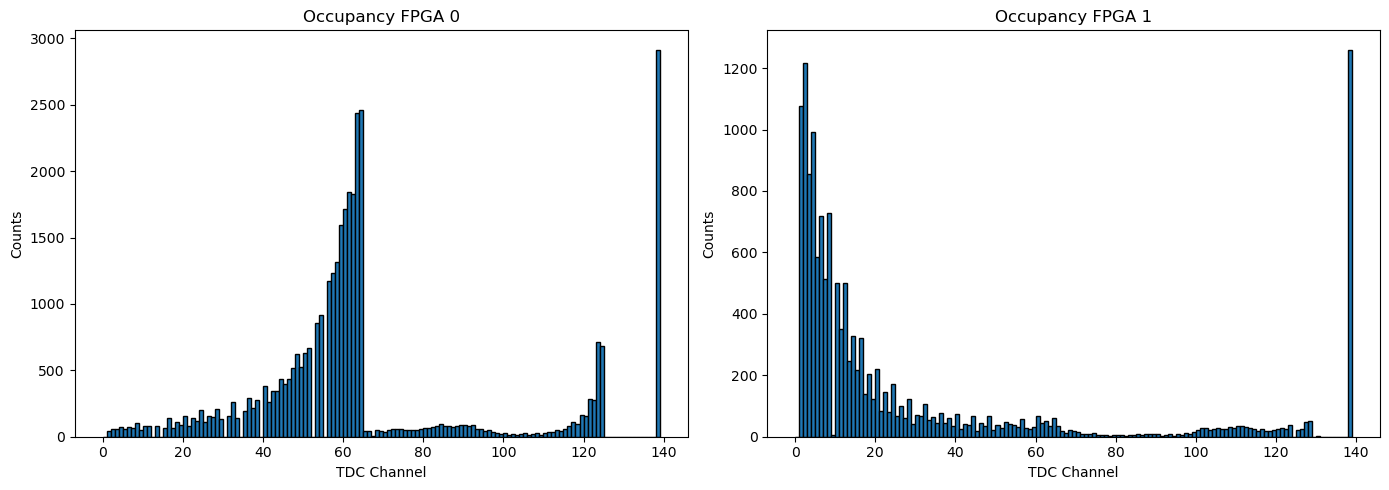


=== Top 3 noisy channels ===
     FPGA  TDC_CHANNEL  counts
117     0          139    2915
56      0           64    2463
55      0           63    2438

Total unique orbits: 498
Unique orbits with TDC_CHANNEL=139: 498


In [11]:
# === VERSION 3: Pandas TDC Analysis ===
# PANDAS = Python library for working with tabular data (like Excel spreadsheets)
# DataFrame = Pandas' main object, think of it as a table with rows and columns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===== 1. LOAD DATA FROM FILE =====
# Goal: Read first N rows from text file into a DataFrame
N = 50000  # Number of rows to read (must be > 10,000)

# pd.read_csv() = reads a CSV/text file and creates a DataFrame
# 'data_000637.txt' = file name (must be in current directory)
# nrows=N = only read the first N rows (not the whole file)
# Result: df is a DataFrame (table) with columns like ORBIT_CNT, BX_COUNTER, etc.
df = pd.read_csv('data_000637.txt', nrows=N)

# len(df) = number of rows in the DataFrame
print(f"Loaded {len(df)} rows")

# df.head() = shows the FIRST 5 ROWS of the DataFrame (useful to see structure)
# This is like looking at the top of an Excel spreadsheet
print(df.head())

# ===== 2. FIND NUMBER OF BX PER ORBIT =====
# Goal: Find how many BX_COUNTER values exist in one ORBIT
# Context: Data has ORBIT_CNT (orbit number) and BX_COUNTER (counter within orbit)

# STEP 1: Group data by ORBIT_CNT
# df.groupby('ORBIT_CNT') = split DataFrame into groups, one group per unique ORBIT_CNT value
# Think: separate the rows into piles based on ORBIT_CNT
# ['BX_COUNTER'] = we only care about the BX_COUNTER column in each group
# .max() = for each group, find the MAXIMUM value of BX_COUNTER
# Result: orbit_groups is a Series (1D array) where:
#   - index = ORBIT_CNT values (e.g., 0, 1, 2, ...)
#   - values = max BX_COUNTER in that orbit
orbit_groups = df.groupby('ORBIT_CNT')['BX_COUNTER'].max()

# STEP 2: Find the overall maximum
# orbit_groups.max() = find the largest value across ALL orbits
# +1 because BX_COUNTER goes from 0 to (x-1), so x is the total count
# Example: if max is 3563, then BX values are 0,1,2,...,3563 → x = 3564
x = orbit_groups.max() + 1
print(f"\nNumber of BX in one ORBIT: {x}")  # Should be 3564

# ===== 3. CALCULATE DATA TAKING DURATION =====
# Goal: Estimate how long data collection took (in seconds)
# Formula: duration = number_of_orbits × BX_per_orbit × 25ns

# df['ORBIT_CNT'] = access the ORBIT_CNT column (like Excel column)
# .max() = find maximum value in that column
# .min() = find minimum value in that column
# Difference gives total number of orbits in dataset
total_orbits = df['ORBIT_CNT'].max() - df['ORBIT_CNT'].min()

# Calculate duration in nanoseconds (ns)
# Each orbit has x BX, each BX is 25ns → orbit duration = x * 25ns
duration_ns = total_orbits * x * 25

# Convert nanoseconds to seconds (1 second = 10^9 nanoseconds)
# 1e-9 = scientific notation for 0.000000001
duration_s = duration_ns * 1e-9
print(f"Data taking duration (estimate): {duration_s:.3f} seconds")

# ===== 4. CREATE NEW COLUMN WITH ABSOLUTE TIME =====
# Goal: Add a new column called 'TIME_NS' with absolute timestamp in nanoseconds

# CREATING NEW COLUMN: df['new_column_name'] = values
# This is like adding a new column in Excel
# This works on ALL ROWS at once (vectorized operation)

# === UNDERSTANDING THE TIME FORMULA ===
# The detector has a hierarchical time structure:
#
# 1. ORBIT_CNT = which orbit (large time unit)
# 2. BX_COUNTER = which BX within that orbit (medium time unit)
# 3. TDC_MEAS = fine measurement within that BX (small time unit)
#
# Think of it like: Hours:Minutes:Seconds
#                   ORBIT : BX : TDC

# --- STEP 1: Convert ORBIT + BX to absolute BX position ---
# (df['ORBIT_CNT'] * x + df['BX_COUNTER'])
# 
# Each orbit contains x BX (x ≈ 3564)
# - Orbit 0: BX positions 0 to (x-1)
# - Orbit 1: BX positions x to (2x-1)  
# - Orbit n: BX positions n*x to (n+1)*x - 1
#
# So: absolute_BX_position = ORBIT_CNT * x + BX_COUNTER
# Example: Orbit 2, BX 10 → position = 2*3564 + 10 = 7138

# --- STEP 2: Convert BX position to nanoseconds ---
# × 25
#
# Each BX (Bunch Crossing) lasts 25 nanoseconds in the LHC
# This is the time between particle bunches passing through the detector
# So we multiply by 25 to convert from BX units to nanoseconds
#
# Example: 7138 BX × 25ns = 178,450 ns

# --- STEP 3: Add fine time measurement from TDC ---
# + df['TDC_MEAS'] * 25/30
#
# TDC = Time-to-Digital Converter (high precision timer)
# The TDC SUBDIVIDES each 25ns BX period into 30 smaller intervals
# So each TDC tick = 25ns ÷ 30 ≈ 0.833 nanoseconds
#
# Why 25/30? Because we need to convert TDC counts to nanoseconds:
# - TDC_MEAS is a number between 0 and 29 (30 subdivisions)
# - Each subdivision = 25ns/30
# - So TDC_MEAS * (25/30) gives the extra time within the BX
#
# Example: If TDC_MEAS = 15, then fine_time = 15 * (25/30) = 12.5ns
#
# SUMMARY:
# - BX_COUNTER uses ×25 because each BX = 25ns (coarse timing)
# - TDC_MEAS uses ×(25/30) because it's a subdivision of the 25ns BX (fine timing)

df['TIME_NS'] = (df['ORBIT_CNT'] * x + df['BX_COUNTER']) * 25 + df['TDC_MEAS'] * 25/30

# ===== 5. MODIFY EXISTING COLUMN =====
# Goal: Replace HEAD column values with random 0 or 1

np.random.seed(42)  # Set random seed for reproducibility

# MODIFYING COLUMN: df['existing_column'] = new_values
# This replaces ALL values in the HEAD column
# np.random.randint(0, 2, len(df)) = generate len(df) random integers, each is 0 or 1
#   - 0 = minimum value (inclusive)
#   - 2 = maximum value (exclusive) → only generates 0 or 1
#   - len(df) = how many random numbers to generate (one per row)
df['HEAD'] = np.random.randint(0, 2, len(df))

# ===== 6. FILTER ROWS (CREATE SUBSET) =====
# Goal: Create new DataFrame containing ONLY rows where HEAD=1

# FILTERING SYNTAX: df[condition]
# df['HEAD'] == 1 = creates a boolean array (True/False for each row)
#   - True where HEAD=1, False where HEAD=0
# df[df['HEAD'] == 1] = keeps only rows where condition is True
# .copy() = create independent copy (not just a view)
#   - Important: without .copy(), changes to df_head1 might affect original df
df_head1 = df[df['HEAD'] == 1].copy()

# len(df_head1) = count rows in filtered DataFrame
print(f"\nRows with HEAD=1: {len(df_head1)}")

# ===== 7. CREATE OCCUPANCY PLOTS =====
# Goal: For each FPGA, plot histogram of TDC_CHANNEL counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loop through both FPGA values (0 and 1)
for fpga, ax in [(0, ax1), (1, ax2)]:
    # FILTER: get only rows where FPGA column equals current fpga value
    # df[df['FPGA'] == fpga] = boolean indexing (same as step 6)
    fpga_data = df[df['FPGA'] == fpga]
    
    # fpga_data['TDC_CHANNEL'] = extract just the TDC_CHANNEL column
    # This gives a Series (1D array) of all TDC_CHANNEL values for this FPGA
    ax.hist(fpga_data['TDC_CHANNEL'], bins=range(0, 140), edgecolor='black')
    ax.set_xlabel('TDC Channel')
    ax.set_ylabel('Counts')
    ax.set_title(f'Occupancy FPGA {fpga}')
plt.tight_layout()
plt.show()

# ===== 8. FIND NOISY CHANNELS (TOP 3 by count) =====
# Goal: Which (FPGA, TDC_CHANNEL) combinations have most measurements?

# STEP 1: Group by multiple columns and count
# df.groupby(['FPGA', 'TDC_CHANNEL']) = group by BOTH columns together
#   - Creates groups for each unique (FPGA, TDC_CHANNEL) pair
#   - Example: (0, 0), (0, 1), (0, 2), ..., (1, 0), (1, 1), ...
# .size() = count number of rows in each group
#   - Returns a Series with MultiIndex (FPGA, TDC_CHANNEL)
# .reset_index(name='counts') = convert to DataFrame with columns:
#   - FPGA, TDC_CHANNEL, counts
#   - reset_index transforms the grouped index back into normal columns
channel_counts = df.groupby(['FPGA', 'TDC_CHANNEL']).size().reset_index(name='counts')

# STEP 2: Find top 3
# .nlargest(3, 'counts') = get the 3 rows with LARGEST values in 'counts' column
# Returns a new DataFrame with just those 3 rows, sorted by counts (descending)
top3 = channel_counts.nlargest(3, 'counts')

print("\n=== Top 3 noisy channels ===")
print(top3)

# ===== 9. COUNT UNIQUE VALUES =====
# Goal: How many different ORBIT_CNT values exist?

# df['ORBIT_CNT'] = get the ORBIT_CNT column (Series)
# .nunique() = count Number of UNIQUE values
#   - If column has [1, 2, 2, 3, 3, 3], nunique() returns 3 (bevause the unique values are: 1, 2, 3) i.e. there are 3 distinct values in the column
n_unique_orbits = df['ORBIT_CNT'].nunique()
print(f"\nTotal unique orbits: {n_unique_orbits}")

# COMBINED OPERATIONS: Filter then count unique
# STEP 1: df[df['TDC_CHANNEL'] == 139] = filter to rows where TDC_CHANNEL=139
# STEP 2: ['ORBIT_CNT'] = from filtered rows, get ORBIT_CNT column
# STEP 3: .nunique() = count unique values in that column
# This is called "method chaining" - operations applied left-to-right
orbits_139 = df[df['TDC_CHANNEL'] == 139]['ORBIT_CNT'].nunique()
print(f"Unique orbits with TDC_CHANNEL=139: {orbits_139}")

### 3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [2]:
# === VERSION 3: Exercise 3 - Monte Carlo: Hit/Miss vs Mean Value ===
import numpy as np

# Function to integrate
def f(x):
    return np.sin(1 / (x * (2 - x)))**2

# Integration limits
a, b = 0.001, 1.999  # avoid singularities at 0 and 2
N = 100000

np.random.seed(42)

# === Method 1: Hit/Miss ===
# Find max of f(x) for bounding box
x_test = np.linspace(a, b, 10000)
f_max = f(x_test).max()

# Generate random points in rectangle [a,b] x [0, f_max]
x_rand = np.random.uniform(a, b, N)
y_rand = np.random.uniform(0, f_max, N)

# Count hits (below the curve)
hits = np.sum(y_rand < f(x_rand))

# Integral = area of rectangle * (hits / total)
area_rect = (b - a) * f_max
integral_hitmiss = area_rect * hits / N
error_hitmiss = area_rect * np.sqrt(hits * (N - hits) / N**3)  # binomial error

print("=== Hit/Miss Method ===")
print(f"Integral: {integral_hitmiss:.4f} ± {error_hitmiss:.4f}")

# === Method 2: Mean Value ===
# Integral ≈ (b-a) * <f(x)>
x_rand = np.random.uniform(a, b, N)
f_vals = f(x_rand)

integral_meanval = (b - a) * np.mean(f_vals)
error_meanval = (b - a) * np.std(f_vals) / np.sqrt(N)

print("\n=== Mean Value Method ===")
print(f"Integral: {integral_meanval:.4f} ± {error_meanval:.4f}")

print("\n=== Comparison ===")
print(f"Mean value error is smaller: more efficient")

print(f_max)

=== Hit/Miss Method ===
Integral: 1.4515 ± 0.0028

=== Mean Value Method ===
Integral: 1.4502 ± 0.0017

=== Comparison ===
Mean value error is smaller: more efficient
0.9999999748685472


### Ex 1 Bash

The following exercise is meant to be solved by gathering the bash commands incrimentally in a script

1\.a Make a new directory called `students` in your home. Download a csv file with the list of students of this lab from [here](https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv) (use the `wget` command) and copy that to `students`. First check whether the file is already there

1\.b Make two new files, one containing the students belonging to PoD, the other to Physics.

1\.c For each letter of the alphabet, count the number of students whose surname starts with that letter. 

1\.d Find out which is the letter with most counts.

1\.e Assume an obvious numbering of the students in the file (first line is 1, second line is 2, etc.), group students "modulo 18", i.e. 1,19,37,.. 2,20,38,.. etc. and put each group in a separate file  

```bash
#!/bin/bash
# ============================================
# BASH EXERCISE 1 - Students Management
# ============================================

# ===== 1.a: Create directory and download file =====
cd $HOME                          # cd = change directory, $HOME = home directory (~)
mkdir -p students                 # mkdir = make directory, -p = create parent dirs if needed
cd students                       # Enter the students directory

# Check if file already exists before downloading
# [ ! -f "filename" ] = TEST if file does NOT exist
#   ! = NOT operator (negation)
#   -f = test if it's a regular file
# if [ condition ]; then ... fi = conditional block (if-then-fi)
if [ ! -f "LCP_22-23_students.csv" ]; then
    # If file doesn't exist, download it
    # wget = download file from URL (wget = "web get")
    wget https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv
fi

# ===== 1.b: Separate students by program =====
# grep = SEARCH for lines containing a pattern
# grep "PoD" file = find all lines containing the text "PoD"
# > filename = REDIRECT output (save the result to a file)
grep "PoD" LCP_22-23_students.csv > pod.csv          # Extract PoD students → save to pod.csv
grep "Physics" LCP_22-23_students.csv > physics.csv  # Extract Physics students → save to physics.csv

# ===== 1.c: Count students by surname initial =====
# for variable in list; do ... done = LOOP through each value
# {A..Z} = expansion: A, B, C, D, ... Z (brace expansion)
# ^ = REGEX anchor meaning "start of line"
# "^$letter" = lines that START with that letter
# -c = COUNT mode (count matches instead of printing them)
# $(command) = COMMAND SUBSTITUTION (execute command and capture output)
for letter in {A..Z}; do
    # Count how many students have surname starting with this letter
    count=$(grep -c "^$letter" LCP_22-23_students.csv)
    # Print the letter and count: "A: 5" "B: 3" etc.
    echo "$letter: $count"
done

# ===== 1.d: Find letter with most students =====
# Initialize variables BEFORE the loop (set their starting values)
# "" = empty string (no value yet)
# 0 = zero
max_letter=""                    # Will store the letter with most students
max_count=0                       # Will store the highest count found

for letter in {A..Z}; do
    # Same counting as 1.c: count students with this letter
    count=$(grep -c "^$letter" LCP_22-23_students.csv)
    
    # [ $count -gt $max_count ] = TEST if count is GREATER THAN max_count
    # -gt = comparison operator ("greater than")
    # Other operators: -lt (less than), -eq (equal), -le (less or equal), -ge (greater or equal)
    if [ $count -gt $max_count ]; then
        # Update the max values when we find a new highest count
        max_count=$count          # Store this count as the new maximum
        max_letter=$letter        # Store this letter
    fi
done
echo "Most common: $max_letter with $max_count students"

# ===== 1.e: Group students modulo 18 =====
# NR = special awk variable meaning "Number of Record" (line number, starts at 1)
# % = MODULO operator (gives the REMAINDER after division)
# NR % 18 = remainder when line number is divided by 18 (gives 0-17)
# Groups: lines 1,19,37,55... → group_1 (remainder=1)
#         lines 2,20,38,56... → group_2 (remainder=2)
#         lines 18,36,54,72... → group_18 (remainder=0 but i%18=0 matches)
for i in {1..18}; do
    # awk = text processing tool
    # 'condition { action }' = if condition is true, execute action
    # This groups students with the same remainder when dividing line number by 18
    # > file = save output to file
    awk "NR % 18 == $i % 18" LCP_22-23_students.csv > group_$i.csv
done
```

## Version 4

### Ex 2 Bash

The following exercise is meant to be solved by gathering the bash commands incrimentally in a script

2.a Make a copy of the file `data.csv` removing the metadata and the commas between numbers; call it `data.txt`

2\.b How many even numbers are there?

2\.c Distinguish the entries on the basis of `sqrt(X^2 + Y^2 + Z^2)` is greater or smaller than `100*sqrt(3)/2`. Count the entries of each of the two groups 

2\.d Make `n` copies of data.txt (with `n` an input parameter of the script), where the i-th copy has all the numbers divided by i (with `1<=i<=n`).

```bash
#!/bin/bash
# ============================================
# BASH EXERCISE 2 - Data Processing
# ============================================

# ===== 2.a: Remove metadata and commas =====
# Lines with # at start are comments (metadata) - we want to REMOVE them
# Commas separate numbers - we want SPACES instead
# grep = search for lines
# -v = invert (find lines that DON'T match - v = "invert")
# ^# = lines starting with # (^ = start of line)
# | = PIPE (send output of left command to right command as input)
# sed = stream editor (find and replace)
# 's/,/ /g' = substitute (s) commas (,) with spaces ( ), globally (g = all occurrences)
# > file = save output to file
grep -v "^#" data.csv | sed 's/,/ /g' > data.txt
# Result: file with no comments (#...) and numbers separated by spaces

# ===== 2.b: Count even numbers =====
# grep -oE = output each match on new line, with extended regex
# '[0-9]+' = regex pattern: one or more digits (+ = one or more)
# This extracts EACH number on a separate line
# awk '$1 % 2 == 0' = keep only lines where the number is EVEN
#   $1 = first field (the number)
#   % 2 = modulo 2 (remainder when divided by 2)
#   == 0 = if remainder is 0 (even number)
# wc -l = count lines (l = lines)
# Piping: extract numbers → filter even → count
grep -oE '[0-9]+' data.txt | awk '$1 % 2 == 0' | wc -l

# ===== 2.c: Distinguish by distance from origin =====
# Calculate sqrt(X²+Y²+Z²) for each row (3D distance from origin)
# Compare with threshold 100*sqrt(3)/2 ≈ 86.6
# SIMPLER AND EASIER TO REMEMBER VERSION:
# $1, $2, $3 = first, second, third field (X, Y, Z values)
# * = multiplication (clearer than ^ for squaring)
# sqrt() = square root function
# {d=...} = calculate distance and store in variable d
# d>86.6{above++} = if distance > 86.6, increment above counter
# d<=86.6{below++} = if distance <= 86.6, increment below counter
# END{print ...} = after all lines, print the two counts
awk '{d=sqrt($1*$1+$2*$2+$3*$3)} d>86.6{above++} d<=86.6{below++} END{print above, below}' data.txt
# Result: two counts - how many rows are above and below the threshold
# Logic: calculate distance → compare → count → display

# ===== 2.d: Make n copies with scaled data =====
# SIMPLER VERSION (without nested loop inside awk):
# $1 = first argument passed to script (number of copies to make)
# n=$1 = store argument in variable n
# seq 1 $n = sequence: 1, 2, 3, ..., n (seq = "sequence")
# $(...) = command substitution (execute and capture output)
# for loop iterates i from 1 to n
n=$1
for i in $(seq 1 $n); do
    # awk -v d=$i = pass variable d with value i to awk
    # {print $1/d, $2/d, $3/d} = print each column divided by d
    # Simpler than looping over NF - we know there are 3 columns (X, Y, Z)
    # > data_$i.txt = save to data_1.txt, data_2.txt, etc.
    awk -v d=$i '{print $1/d, $2/d, $3/d}' data.txt > data_$i.txt
done
# Result: n files (data_1.txt, data_2.txt, ..., data_n.txt)
#         where each file has all numbers divided by the file number
# Logic: For each copy i → divide X, Y, Z by i → save
```

### 2\. Find the outer product of the following two vecotrs

```python
u = np.array([1,3,5,7])
v = np.array([2,4,6,8])
```

Do this in the following ways:

   * Using the function outer in numpy
   * Using a nested for loop or list comprehension
   * Using numpy broadcasting operatoins


In [13]:
# === VERSION 4: Exercise 2 - Outer Product ===
import numpy as np

u = np.array([1, 3, 5, 7])
v = np.array([2, 4, 6, 8])

# === Method 1: numpy.outer ===
outer1 = np.outer(u, v)
print("Method 1 - np.outer:")
print(outer1)

# === Method 2: Nested loop / list comprehension ===
# element (i,j) = Ui*Vj
outer2 = np.array([[ui * vj for vj in v] for ui in u])
print("\nMethod 2 - List comprehension:")
print(outer2)

# === Method 3: Broadcasting ===
# Make u a column vector (4,1) and v a row vector (1,4)
outer3 = u[:, np.newaxis] * v[np.newaxis, :]
# Equivalent: u.reshape(-1, 1) * v.reshape(1, -1)
print("\nMethod 3 - Broadcasting:")
print(outer3)

# Verify all methods give same result
print(f"\nAll methods equal: {np.allclose(outer1, outer2) and np.allclose(outer1, outer3)}")

Method 1 - np.outer:
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]

Method 2 - List comprehension:
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]

Method 3 - Broadcasting:
[[ 2  4  6  8]
 [ 6 12 18 24]
 [10 20 30 40]
 [14 28 42 56]]

All methods equal: True


### 4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



In [14]:
# === VERSION 4: Exercise 4 - Monte Carlo in High Dimensions ===
import numpy as np

np.random.seed(42)
N = 1_000_000

# === 2D Circle (radius=1) ===
# Sample in square [-1, 1]² and count points inside circle
x = np.random.uniform(-1, 1, (N, 2))
r2 = np.sum(x**2, axis=1)  # x² + y²
inside_2d = np.sum(r2 <= 1)

# Area = (side length)² * fraction inside = 4 * (inside/N)
area_2d = 4 * inside_2d / N
print(f"=== 2D Circle ===")
print(f"Estimated area: {area_2d:.4f}")
print(f"Exact (π): {np.pi:.4f}")
print(f"Error: {abs(area_2d - np.pi):.4f}")

# === 10D Sphere (radius=1) ===
d = 10
x = np.random.uniform(-1, 1, (N, d))
r2 = np.sum(x**2, axis=1)
inside_10d = np.sum(r2 <= 1)

# Volume = (2^d) * fraction inside
volume_10d = (2**d) * inside_10d / N

# Exact formula: V_n = π^(n/2) / Γ(n/2 + 1)
from scipy.special import gamma
exact_10d = np.pi**(d/2) / gamma(d/2 + 1)

print(f"\n=== 10D Sphere ===")
print(f"Estimated volume: {volume_10d:.4f}")
print(f"Exact: {exact_10d:.4f}")
print(f"Error: {abs(volume_10d - exact_10d):.4f}")

=== 2D Circle ===
Estimated area: 3.1420
Exact (π): 3.1416
Error: 0.0004

=== 10D Sphere ===
Estimated volume: 2.5344
Exact: 2.5502
Error: 0.0158


### 5\. **FFT of an image**

* Examine the provided image `moonlanding.png`, which is heavily contaminated with periodic noise. In this exercise, we aim to clean up the noise using the Fast Fourier Transform.
* Load the image using pylab.imread().
* Find and use the 2-D FFT function in scipy.fftpack, and plot the spectrum (Fourier transform of) the image. Do you have any trouble visualising the spectrum? If so, why?
* The spectrum consists of high and low frequency components. The noise is contained in the high-frequency part of the spectrum, so set some of those components to zero (use array slicing).
* Apply the inverse Fourier transform to see the resulting image.

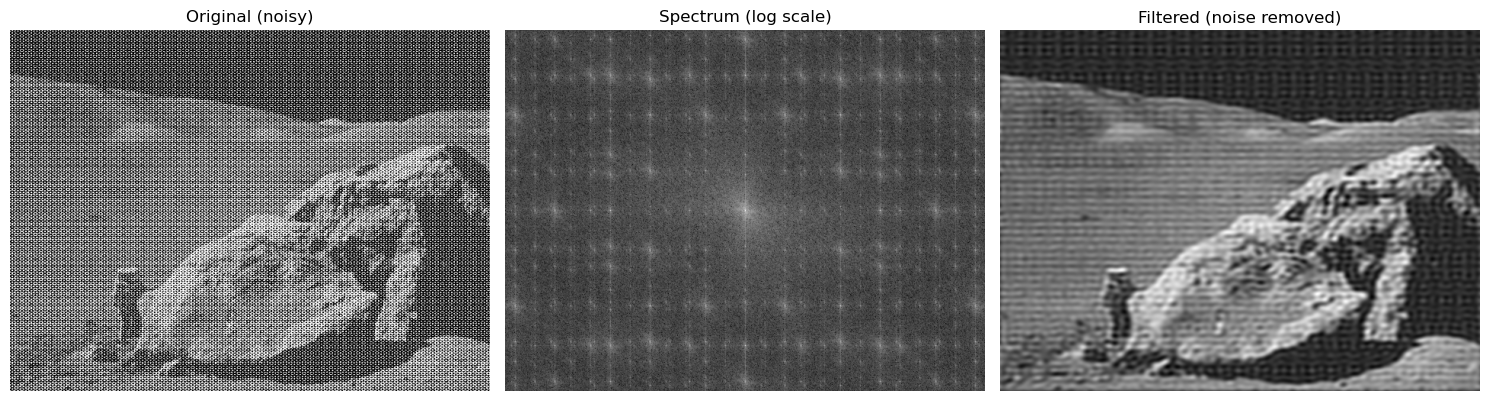

In [15]:
# === VERSION 4: Exercise 5 - FFT of Moon Landing Image ===
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack

# Load image (you need moonlanding.png in the folder)
img = plt.imread('moonlanding.png')

# If not available, use scipy's sample
# try:
#     img = plt.imread('moonlanding.png')
# except:
#     from scipy import datasets
#     img = datasets.ascent()  # fallback sample image

# # Convert to grayscale if needed
# if len(img.shape) == 3:
#     img = img.mean(axis=2)

# === Original image ===
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original (noisy)')
plt.axis('off')

# === 2D FFT ===
F = fftpack.fft2(img)
F_shifted = fftpack.fftshift(F)  # center the zero frequency

# Plot spectrum (use log scale for visibility!)
plt.subplot(1, 3, 2)
plt.imshow(np.log(np.abs(F_shifted) + 1), cmap='gray')
plt.title('Spectrum (log scale)')
plt.axis('off')

# === Filter high frequencies (noise) ===
# Create a mask to keep low frequencies (center of spectrum)
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2

# Low-pass filter: keep center (low freq), remove outer (high freq = noise)
# Step 1: Initialize mask as all zeros (0 = block frequency, 1 = keep frequency)
mask = np.zeros((rows, cols))

# Step 2: Define radius of circular region to preserve
r = 60  # radius in pixels - larger r = more frequencies kept = less blur but more noise

# Step 3: Create coordinate grids for each pixel position
# np.ogrid creates "open" grids efficiently:
#   y is a column vector: [[0], [1], [2], ..., [rows-1]]  (shape: rows×1)
#   x is a row vector: [[0, 1, 2, ..., cols-1]]           (shape: 1×cols)
# When used in operations, broadcasting automatically creates full 2D grids
y, x = np.ogrid[:rows, :cols]

# Step 4: Circle equation to identify pixels inside the circle
# For each pixel at position (x, y), calculate: (x - center_x)² + (y - center_y)² ≤ r²
# This creates a boolean array: True = inside circle, False = outside circle
# The circle is centered at (crow, ccol), which is the center of the FFT spectrum
# (center = low frequencies, edges = high frequencies)
mask_area = (x - ccol)**2 + (y - crow)**2 <= r**2

# Step 5: Set mask to 1 for pixels inside the circle (keep these frequencies)
# All other pixels remain 0 (block these frequencies)
# Result: circular white disk (1) in center, black (0) everywhere else
mask[mask_area] = 1

# Apply mask
F_filtered = F_shifted * mask

# === Inverse FFT ===
F_ishifted = fftpack.ifftshift(F_filtered)
img_filtered = np.real(fftpack.ifft2(F_ishifted))

plt.subplot(1, 3, 3)
plt.imshow(img_filtered, cmap='gray')
plt.title('Filtered (noise removed)')
plt.axis('off')

plt.tight_layout()
plt.show()


### 3\. **Profile plot**

Produce a profile plot from a scatter plot.
* Download the following dataset and load it as a pandas dataframe:
```bash
wget https://www.dropbox.com/s/hgnvyj9abatk8g6/residuals_261.npy
```
Note that you should use the `np.load()` function to load the file as a numpy array, call the `.item()` method, and then pass it to the `pd.DataFrame()` constructor.
* Inspect the dataset, you'll find two variables (features)
* Clean the sample by selecting the entries (rows) with the variable "residual" in absolute value smaller than 2
* perform a linear regression of "residuals" versus "distances" using `scipy.stats.linregress()` 
* plot a seaborn jointplot of  "residuals" versus "distances", having seaborn performing a linear regression. The result of the regression should be displayed on the plot
* Fill 3 numpy arrays
  * x, serving as an array of bin centers for the "distance" variable. It should range from 0 to 20 with reasonable number of steps (bins)
  * y, the mean values of the "residuals", estimated in slices (bins) of "distance"
  * erry, the standard deviation of the  of the "residuals", estimated in slices (bins) of "distance"
* Plot the profile plot on top of the scatter plot

Columns: ['residuals', 'distances']
   residuals  distances
0       1.10       16.0
1      -1.95        6.3
2      -7.20        3.4
3      -4.15        8.4
4      -6.59        1.7

Original: 11131 rows, Cleaned: 10489 rows

Linear regression: y = 0.0033x + -0.1543, r² = 0.0019


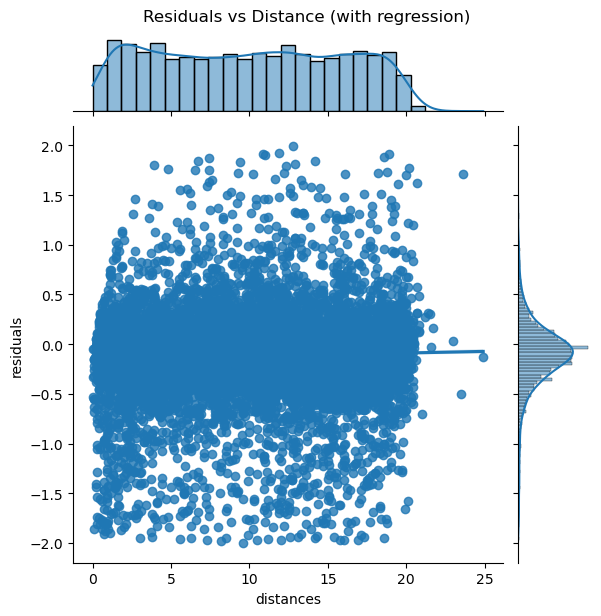

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_29564\2318691021.py:96: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_clean.groupby('bin')['residuals']


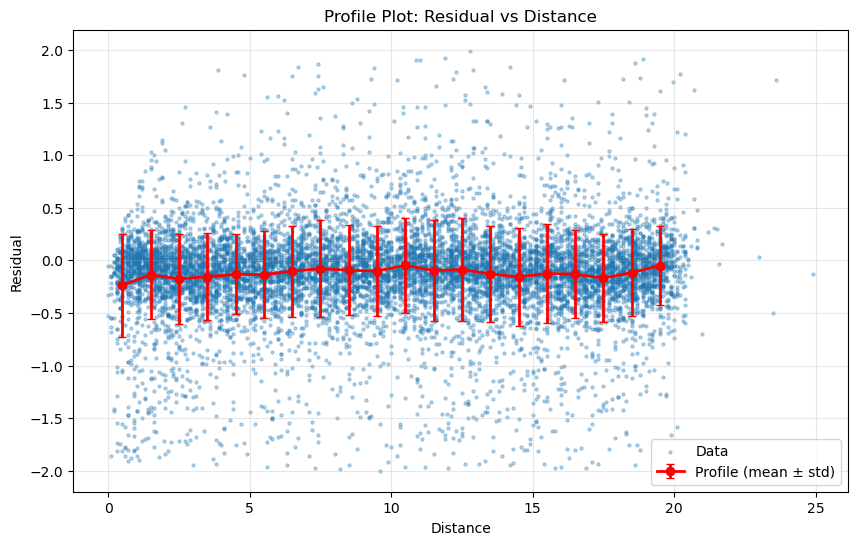

In [ ]:
# === VERSION 4: Exercise 3 - Profile Plot ===
# A PROFILE PLOT shows the average behavior of Y (residuals) across ranges of X (distances)
# Instead of plotting thousands of noisy scatter points, we:
# 1. Divide X-axis into bins (like a histogram)
# 2. In each bin, calculate MEAN and STD of Y values
# 3. Plot these statistics to see the trend more clearly

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# === STEP 1: Load and explore data ===
# The .npy file contains residuals (errors) from some model vs distances
data = np.load('residuals_261.npy', allow_pickle=True).item()
df = pd.DataFrame(data)
print("Columns:", df.columns.tolist())
print(df.head())

# === STEP 2: Data cleaning ===
# Remove outliers: keep only points where |residual| < 2
# This filters extreme values that might be measurement errors
df_clean = df[np.abs(df['residuals']) < 2].copy()
print(f"\nOriginal: {len(df)} rows, Cleaned: {len(df_clean)} rows")

# === STEP 3: Linear regression ===
# Fit a line to see if residuals correlate with distance
# y = slope*x + intercept
slope, intercept, r, p, se = stats.linregress(df_clean['distances'], df_clean['residuals'])
print(f"\nLinear regression: y = {slope:.4f}x + {intercept:.4f}, r² = {r**2:.4f}")

# === STEP 4: Visualization with regression line ===
# Seaborn jointplot: scatter + marginal histograms + regression line
g = sns.jointplot(data=df_clean, x='distances', y='residuals', kind='reg', height=6)
g.figure.suptitle('Residuals vs Distance (with regression)', y=1.02)
plt.show()

# === STEP 5: CREATE PROFILE PLOT ===
# Goal: Reduce noise by averaging residuals in distance bins

# Define bins: divide distance range [0, 20] into 20 equal bins
n_bins = 20
bin_edges = np.linspace(0, 20, n_bins + 1)  # Creates 21 edges: [0, 1, 2, ..., 20]
# Calculate bin centers: midpoint between consecutive edges
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # [0.5, 1.5, 2.5, ..., 19.5]

# Initialize arrays to store profile statistics
x = bin_centers  # X-coordinates for profile plot
y = np.zeros(n_bins)  # Mean of residuals in each bin
erry = np.zeros(n_bins)  # Standard deviation of residuals in each bin

# old step 6
# # === STEP 6: Calculate mean and std for each distance bin ===
# for i in range(n_bins):
#     # Create boolean mask: TRUE for points in current bin
#     # Example: bin 0 includes distances in [0, 1), bin 1 in [1, 2), etc.
#     mask = (df_clean['distances'] >= bin_edges[i]) & (df_clean['distances'] < bin_edges[i+1])
    
#     # Check if bin has data (avoid empty bins)
#     if mask.sum() > 0:
#         # Calculate MEAN of all residuals in this bin → y[i]
#         y[i] = df_clean.loc[mask, 'residuals'].mean()
#         # Calculate STD (spread) of residuals in this bin → erry[i]
#         erry[i] = df_clean.loc[mask, 'residuals'].std()
#     # If bin is empty, y[i] and erry[i] remain 0


# new step 6 much simpler
# === STEP 6: Calculate mean and std for each distance bin (OPTIMIZED VERSION) ===

# ========== METHOD 1: pd.cut() + groupby() (RECOMMENDED - Faster and more readable) ==========

# STEP 6.1: Create a 'bin' column that assigns each distance to the correct interval
# pd.cut(data, bins=edges) = divide the data into bins based on the edges
#   - Each element of 'distances' is assigned to an interval
#   - The intervals are: [0,1), [1,2), [2,3), ..., [19,20)
#   - Result: a column with values like "(0, 1]", "(1, 2]", etc.
# 
# Example:
#   distances = [0.5, 1.3, 1.8, 2.1, ...]
#   after pd.cut:
#   bin = ["(0, 1]", "(1, 2]", "(1, 2]", "(2, 3]", ...]
df_clean['bin'] = pd.cut(df_clean['distances'], bins=bin_edges)

# STEP 6.2: Group the data by bin
# df_clean.groupby('bin') = divide the DataFrame into groups according to the 'bin' column
#   - Creates one group for each unique interval
#   - Each group contains all rows that belong to that bin
# ['residuals'] = keep only the 'residuals' column in each group
#   - We only need the residuals to calculate mean/std
#
# Result: a GroupBy object that contains:
#   Group 1 (bin "(0, 1]"): [0.1, 0.2, 0.15, ...]  (residuals of points in [0,1))
#   Group 2 (bin "(1, 2]"): [0.05, -0.1, 0.3, ...]  (residuals of points in [1,2))
#   etc.
grouped = df_clean.groupby('bin')['residuals']

# STEP 6.3: Calculate the MEAN of residuals in each bin
# grouped.mean() = for each group, calculate the average
#   - Returns a Series with index = bins, values = means
#   - Result: [0.15, 0.083, 0.12, ...]  (one mean per bin)
# .values = convert the Series to a numpy array (remove the index labels)
#   - We only want the numbers, not the bin names
#
# Example:
#   grouped.mean() = Series([(0,1] → 0.15, (1,2] → 0.083, ...])
#   grouped.mean().values = array([0.15, 0.083, ...])
y = grouped.mean().values

# STEP 6.4: Calculate the STANDARD DEVIATION (std) of residuals in each bin
# grouped.std() = for each group, calculate the standard deviation
#   - Measures the SPREAD of residuals around the mean
#   - Larger values mean residuals are more scattered
#   - This becomes the "error bar" (errbar) in the plot
# .values = convert to numpy array
#
# Example:
#   grouped.std() = Series([(0,1] → 0.05, (1,2] → 0.08, ...])
#   grouped.std().values = array([0.05, 0.08, ...])
erry = grouped.std().values

# ========== COMPARISON: METHOD 2 (For loop - AVOID THIS) ==========
# 
# # This version is more verbose and slower (avoid if possible!)
# for i in range(n_bins):
#     # Create a boolean mask: TRUE for distances in bin i
#     mask = (df_clean['distances'] >= bin_edges[i]) & (df_clean['distances'] < bin_edges[i+1])
#     
#     # Check that the bin is not empty (otherwise std() fails)
#     if mask.sum() > 0:
#         # Calculate the mean for this bin
#         y[i] = df_clean.loc[mask, 'residuals'].mean()
#         # Calculate the standard deviation for this bin
#         erry[i] = df_clean.loc[mask, 'residuals'].std()


# ========== FINAL RESULT ==========
# 
# Now we have:
#   x = [0.5, 1.5, 2.5, ..., 19.5]      # Bin centers
#   y = [0.15, 0.083, 0.12, ...]        # Mean of residuals per bin
#   erry = [0.05, 0.08, 0.06, ...]      # Standard deviation per bin
#
# These three arrays are ready to be plotted with errorbar()!



# === STEP 7: Plot original data + profile ===
plt.figure(figsize=(10, 6))

# Background: all individual data points (noisy, hard to see trend)
plt.scatter(df_clean['distances'], df_clean['residuals'], 
            alpha=0.3,  # semi-transparent to show density
            s=5,  # small points
            label='Data')

# Foreground: PROFILE = mean ± std per bin (clear trend!)
# fmt='ro-': red circles connected by lines
# yerr=erry: vertical error bars showing ± 1 standard deviation
# capsize=3: horizontal caps on error bars
plt.errorbar(x, y, yerr=erry, 
             fmt='ro-',  # red circles with line
             capsize=3,  # error bar caps
             linewidth=2, 
             label='Profile (mean ± std)')

plt.xlabel('Distance')
plt.ylabel('Residual')
plt.title('Profile Plot: Residual vs Distance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## Version 5

### 8\. Diffusion using random walk

Consider a simple random walk process: at each step in time, a walker jumps right or left (+1 or -1) with equal probability. The goal is to find the typical distance from the origin of a random walker after a given amount of time. 
To do that, let's simulate many walkers and create a 2D array with each walker as a row and the actual time evolution as columns

  * Take 1000 walkers and let them walk for 200 steps
  * Use randint to create a 2D array of size walkers x steps with values -1 or 1
  * Build the actual walking distances for each walker (i.e. another 2D array "summing on each row")
  * Take the square of that 2D array (elementwise)
  * Compute the mean of the squared distances at each step (i.e. the mean along the columns)
  * Plot the average distances (sqrt(distance\*\*2)) as a function of time (step)
  
Did you get what you expected?

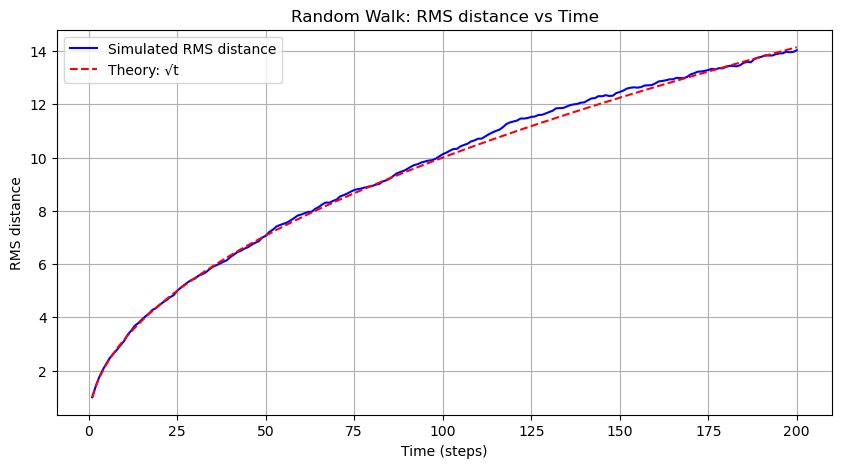

In [17]:
# === VERSION 5: Exercise 8 - Random Walk Diffusion ===
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Parameters
n_walkers = 1000
n_steps = 200

# Generate random steps: -1 or +1 for each walker at each step
# Use randint to generate 0 or 1, then convert to -1 or 1
# randint(0, 2) gives 0 or 1, then: 2*value - 1 converts 0→-1, 1→+1
# Shape: (n_walkers, n_steps)
steps = 2 * np.random.randint(0, 2, size=(n_walkers, n_steps)) - 1

# Cumulative position: sum along rows (axis=1)
# positions[i, t] = position of walker i at time t
positions = np.cumsum(steps, axis=1)

# Square of distances
positions_squared = positions**2

# Mean squared displacement at each time step (average over walkers)
mean_sq_dist = np.mean(positions_squared, axis=0)

# RMS distance = sqrt(mean squared distance)
rms_distance = np.sqrt(mean_sq_dist)

# Time array
time = np.arange(1, n_steps + 1)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(time, rms_distance, 'b-', label='Simulated RMS distance')
plt.plot(time, np.sqrt(time), 'r--', label='Theory: √t')
plt.xlabel('Time (steps)')
plt.ylabel('RMS distance')
plt.title('Random Walk: RMS distance vs Time')
plt.legend()
plt.grid(True)
plt.show()

# Expected: RMS distance ~ √t (diffusion)


### 2\. **Color-coded scatter plot**

Produce a scatter plot out of a dataset with two categories

* Write a function that generate a 2D datasets of 2 categories. Each category should distribute as a 2D gaussian with a given mean and std (clearly it is better to have different values means..)
* Display the dataset in a scatter plot marking the two categories with different marker colors.

An example is given below

You can try to make the procedure more general by allowing a given number $n\ge 2$ of categories

'wget' is not recognized as an internal or external command,
operable program or batch file.


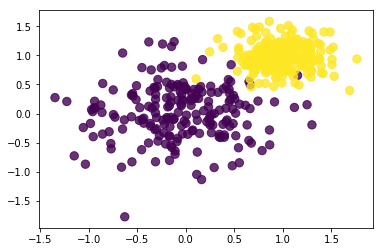

In [18]:
! wget https://www.dropbox.com/s/u4y3k4kk5tc7j46/two_categories_scatter_plot.png
from IPython.display import Image
Image('two_categories_scatter_plot.png')

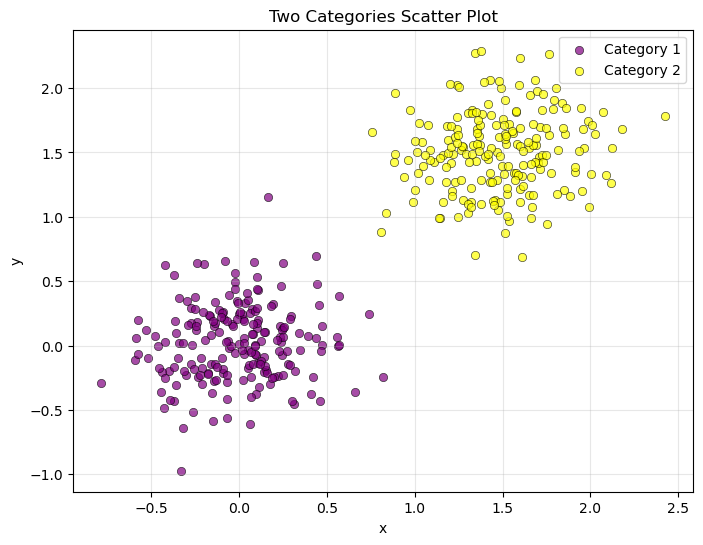

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_29564\3491408247.py:44: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10')


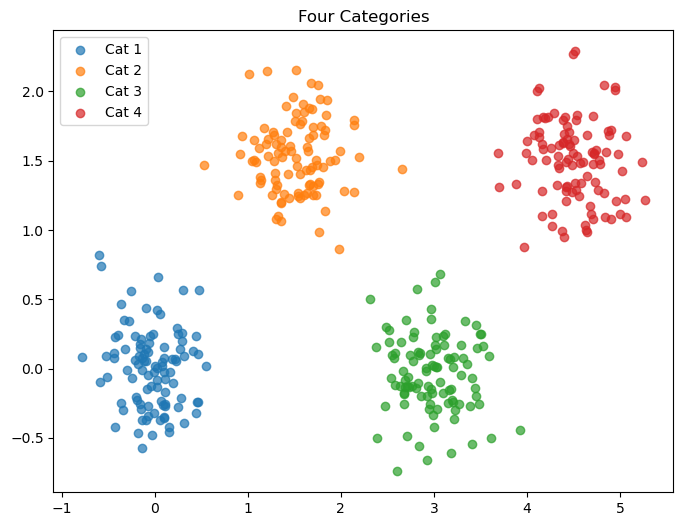

In [19]:
# === VERSION 5: Exercise 2 - Color-coded Scatter Plot ===
import numpy as np
import matplotlib.pyplot as plt

def generate_2d_categories(n_points=200, n_categories=2, seed=42):
    """Generate 2D Gaussian data for multiple categories."""
    np.random.seed(seed)
    
    # Different means for each category (spread them out)
    means = [(i * 1.5, (i % 2) * 1.5) for i in range(n_categories)]
    stds = [0.3] * n_categories  # same std for all
    
    data = []
    labels = []
    for i, (mean, std) in enumerate(zip(means, stds)):
        x = np.random.normal(mean[0], std, n_points)
        y = np.random.normal(mean[1], std, n_points)
        data.append(np.column_stack([x, y]))
        labels.append(np.full(n_points, i))
    
    return np.vstack(data), np.hstack(labels)

# Generate data with 2 categories
data, labels = generate_2d_categories(n_points=200, n_categories=2)

# Plot with different colors
plt.figure(figsize=(8, 6))
colors = ['purple', 'yellow']
for i in range(2):
    mask = labels == i
    plt.scatter(data[mask, 0], data[mask, 1], c=colors[i], 
                label=f'Category {i+1}', alpha=0.7, edgecolors='k', linewidth=0.5)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Two Categories Scatter Plot')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# === Generalized for n categories ===
data_n, labels_n = generate_2d_categories(n_points=100, n_categories=4)
plt.figure(figsize=(8, 6))
cmap = plt.cm.get_cmap('tab10')
for i in range(4):
    mask = labels_n == i
    plt.scatter(data_n[mask, 0], data_n[mask, 1], c=[cmap(i)], label=f'Cat {i+1}', alpha=0.7)
plt.legend()
plt.title('Four Categories')
plt.show()


### 1\. **Maximum wind speed prediction at the Sprogø station**

The exercise goal is to predict the maximum wind speed occurring every 50 years even if no measure exists for such a period. The available data are only measured over 21 years at the Sprogø meteorological station located in Denmark. 

The annual maxima are supposed to fit a normal probability density function. However such function is not going to be estimated because it gives a probability from a wind speed maxima. Finding the maximum wind speed occurring every 50 years requires the opposite approach, the result needs to be found from a defined probability. That is the quantile function role and the exercise goal will be to find it. In the current model, it is supposed that the maximum wind speed occurring every 50 years is defined as the upper 2% quantile.

By definition, the quantile function is the inverse of the cumulative distribution function. The latter describes the probability distribution of an annual maxima. In the exercise, the cumulative probability $p_i$ for a given year i is defined as $p_i = i/(N+1)$ with $N = 21$, the number of measured years. Thus it will be possible to calculate the cumulative probability of every measured wind speed maxima. From those experimental points, the scipy.interpolate module will be very useful for fitting the quantile function. Finally the 50 years maxima is going to be evaluated from the cumulative probability of the 2% quantile.

Practically, load the dataset:

```python
import numpy as np
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]
```

Compute then the cumulative probability $p_i$ (`cprob`) and sort the maximum speeds from the data. Use then the  UnivariateSpline from scipy.interpolate to define a quantile function and thus estimate the probabilities.

In the current model, the maximum wind speed occurring every 50 years is defined as the upper 2% quantile. As a result, the cumulative probability value will be:

```python
fifty_prob = 1. - 0.02
```

So the storm wind speed occurring every 50 years can be guessed as:

``` python
fifty_wind = quantile_func(fifty_prob)
```



Number of years: 21
Max speeds: [28.09 22.46 26.65 26.65 28.79 30.19 26.19 26.75 23.34 24.16 29.75 27.93
 26.68 23.85 32.97 25.79 26.37 25.28 26.73 23.2  26.76]


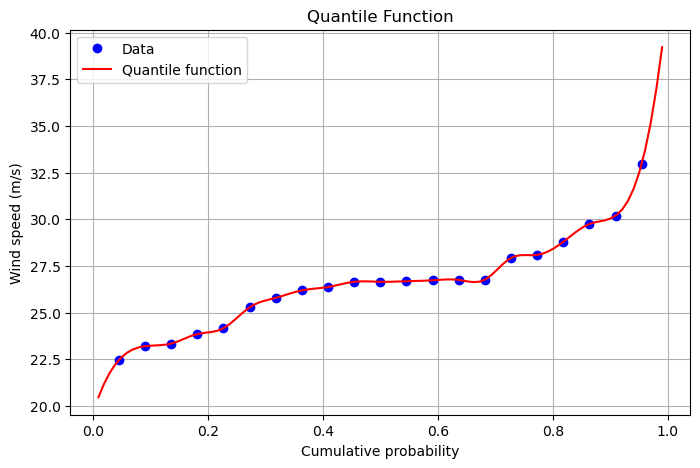


=== 50-year maximum wind speed ===
Probability: 0.98
Estimated wind speed: 36.97 m/s


In [20]:
# === VERSION 5: Exercise 1 - Maximum Wind Speed Prediction ===
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

# Load data (max-speeds.npy should be in the folder)
max_speeds = np.load('max-speeds.npy')
years_nb = max_speeds.shape[0]  # 21 years

print(f"Number of years: {years_nb}")
print(f"Max speeds: {max_speeds}")

# Cumulative probability for each year: p_i = i / (N + 1)
cprob = np.arange(1, years_nb + 1) / (years_nb + 1)

# Sort speeds (needed for interpolation)
sorted_speeds = np.sort(max_speeds)

# Create quantile function using spline interpolation
# Quantile function: given probability p, returns the wind speed
quantile_func = UnivariateSpline(cprob, sorted_speeds, s=0)  # s=0 for exact interpolation

# Plot quantile function
p_range = np.linspace(0.01, 0.99, 100)
plt.figure(figsize=(8, 5))
plt.plot(cprob, sorted_speeds, 'bo', label='Data')
plt.plot(p_range, quantile_func(p_range), 'r-', label='Quantile function')
plt.xlabel('Cumulative probability')
plt.ylabel('Wind speed (m/s)')
plt.title('Quantile Function')
plt.legend()
plt.grid(True)
plt.show()

# 50-year maximum: upper 2% quantile → cumulative probability = 1 - 0.02 = 0.98
fifty_prob = 1 - 0.02
fifty_wind = quantile_func(fifty_prob)

print(f"\n=== 50-year maximum wind speed ===")
print(f"Probability: {fifty_prob}")
print(f"Estimated wind speed: {fifty_wind:.2f} m/s")

### 5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [21]:
# === VERSION 5: Exercise 5 - Monte Carlo with Importance Sampling ===
import numpy as np

# Integral: I = ∫₀¹ x^(-1/2) / (e^x + 1) dx
# Weight function: w(x) = 1/√x
# f(x) / w(x) = 1 / (e^x + 1)

# Importance sampling formula:
# I = ∫ f(x) dx = ∫ [f(x)/w(x)] * w(x) dx
# With w(x) = 1/√x, we need samples from PDF p(x) ∝ w(x)
# p(x) = w(x) / ∫w(x)dx = (1/√x) / 2 = 1/(2√x)  for x ∈ [0,1]

# To sample from p(x) = 1/(2√x), use inverse transform:
# CDF: P(x) = √x, so x = u² where u ~ U(0,1)

np.random.seed(42)
N = 1_000_000

# Generate samples from p(x) = 1/(2√x) using x = u²
u = np.random.uniform(0, 1, N)
x = u**2  # samples distributed as 1/(2√x)

# Integrand divided by weight: f(x)/w(x) = 1/(e^x + 1)
# Integral of w(x) from 0 to 1: ∫₀¹ 1/√x dx = 2
g = 1 / (np.exp(x) + 1)

# Importance sampling estimate: I = ∫w(x)dx * <g(x)> = 2 * mean(g)
integral = 2 * np.mean(g)
error = 2 * np.std(g) / np.sqrt(N)

print("=== Importance Sampling ===")
print(f"Integral: {integral:.4f} ± {error:.4f}")
print(f"Expected: ~0.84")

=== Importance Sampling ===
Integral: 0.8388 ± 0.0001
Expected: ~0.84


### Ex 1 Bash

The following exercise is meant to be solved by gathering the bash commands incrimentally in a script

1\.a Make a new directory called `students` in your home. Download a csv file with the list of students of this lab from [here](https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv) (use the `wget` command) and copy that to `students`. First check whether the file is already there

1\.b Make two new files, one containing the students belonging to PoD, the other to Physics.

1\.c For each letter of the alphabet, count the number of students whose surname starts with that letter. 

1\.d Find out which is the letter with most counts.

1\.e Assume an obvious numbering of the students in the file (first line is 1, second line is 2, etc.), group students "modulo 18", i.e. 1,19,37,.. 2,20,38,.. etc. and put each group in a separate file  

```bash
#!/bin/bash
# ============================================
# BASH EXERCISE 1 - Students Management
# ============================================

# ===== 1.a: Create directory and download file =====
cd $HOME                          # cd = change directory, $HOME = home directory (~)
mkdir -p students                 # mkdir = make directory, -p = create parent dirs if needed
cd students                       # Enter the students directory

# Check if file already exists before downloading
# [ ! -f "filename" ] = TEST if file does NOT exist
#   ! = NOT operator (negation)
#   -f = test if it's a regular file
# if [ condition ]; then ... fi = conditional block (if-then-fi)
if [ ! -f "LCP_22-23_students.csv" ]; then
    # If file doesn't exist, download it
    # wget = download file from URL (wget = "web get")
    wget https://www.dropbox.com/s/867rtx3az6e9gm8/LCP_22-23_students.csv
fi

# ===== 1.b: Separate students by program =====
# grep = SEARCH for lines containing a pattern
# grep "PoD" file = find all lines containing the text "PoD"
# > filename = REDIRECT output (save the result to a file)
grep "PoD" LCP_22-23_students.csv > pod.csv          # Extract PoD students → save to pod.csv
grep "Physics" LCP_22-23_students.csv > physics.csv  # Extract Physics students → save to physics.csv

# ===== 1.c: Count students by surname initial =====
# for variable in list; do ... done = LOOP through each value
# {A..Z} = expansion: A, B, C, D, ... Z (brace expansion)
# ^ = REGEX anchor meaning "start of line"
# "^$letter" = lines that START with that letter
# -c = COUNT mode (count matches instead of printing them)
# $(command) = COMMAND SUBSTITUTION (execute command and capture output)
for letter in {A..Z}; do
    # Count how many students have surname starting with this letter
    count=$(grep -c "^$letter" LCP_22-23_students.csv)
    # Print the letter and count: "A: 5" "B: 3" etc.
    echo "$letter: $count"
done

# ===== 1.d: Find letter with most students =====
# Initialize variables BEFORE the loop (set their starting values)
# "" = empty string (no value yet)
# 0 = zero
max_letter=""                    # Will store the letter with most students
max_count=0                       # Will store the highest count found

for letter in {A..Z}; do
    # Same counting as 1.c: count students with this letter
    count=$(grep -c "^$letter" LCP_22-23_students.csv)
    
    # [ $count -gt $max_count ] = TEST if count is GREATER THAN max_count
    # -gt = comparison operator ("greater than")
    # Other operators: -lt (less than), -eq (equal), -le (less or equal), -ge (greater or equal)
    if [ $count -gt $max_count ]; then
        # Update the max values when we find a new highest count
        max_count=$count          # Store this count as the new maximum
        max_letter=$letter        # Store this letter
    fi
done
echo "Most common: $max_letter with $max_count students"

# ===== 1.e: Group students modulo 18 =====
# NR = special awk variable meaning "Number of Record" (line number, starts at 1)
# % = MODULO operator (gives the REMAINDER after division)
# NR % 18 = remainder when line number is divided by 18 (gives 0-17)
# Groups: lines 1,19,37,55... → group_1 (remainder=1)
#         lines 2,20,38,56... → group_2 (remainder=2)
#         lines 18,36,54,72... → group_18 (remainder=0 but i%18=0 matches)
for i in {1..18}; do
    # awk = text processing tool
    # 'condition { action }' = if condition is true, execute action
    # This groups students with the same remainder when dividing line number by 18
    # > file = save output to file
    awk "NR % 18 == $i % 18" LCP_22-23_students.csv > group_$i.csv
done
```